# Individual Household Electric Power Consumption — Regression Case Study

## Step 1: Project Setup — Directory Structure & Data Acquisition

Before touching any data, we set up a clean, reproducible project structure. This is standard practice in professional data science workflows — it keeps raw data immutable, separates it from cleaned/processed outputs, and gives charts and reports dedicated homes so nothing gets overwritten or lost as the project grows.

We'll create four folders:
- **`Raw_Datasets/`** — the untouched original data, exactly as downloaded. We never edit files here.
- **`Cleaned_Datasets/`** — our processed, model-ready outputs, saved at each major milestone.
- **`Charts/`** — all visualizations exported during EDA and later analysis.
- **`Reports/`** — summary documents, findings, and writeups.

We'll then import our core libraries and pull the dataset directly via the `ucimlrepo` package (id=235), which returns the data as pandas DataFrames — no manual CSV wrangling needed. We'll also save a raw copy into `Raw_Datasets/` immediately, so we always have an untouched baseline to fall back on regardless of how the ucimlrepo package behaves in the future.

In [1]:
# =========================================================
# STEP 1: Project Setup — Directory Structure & Data Acquisition
# =========================================================

import os
import pandas as pd
import numpy as np

# ---- 1.1 Create project directory structure ----
project_dirs = ["Raw_Datasets", "Cleaned_Datasets", "Charts", "Reports"]

for folder in project_dirs:
    os.makedirs(folder, exist_ok=True)
    print(f"Directory ready: {folder}/")

# ---- 1.2 Install & import ucimlrepo (run once; comment out after first install) ----
# !pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# ---- 1.3 Fetch the dataset ----
individual_household_electric_power_consumption = fetch_ucirepo(id=235)

# Features (X) and targets (y) as pandas DataFrames
X = individual_household_electric_power_consumption.data.features
y = individual_household_electric_power_consumption.data.targets

# ---- 1.4 Inspect metadata & variable info ----
print(individual_household_electric_power_consumption.metadata)
print(individual_household_electric_power_consumption.variables)

# ---- 1.5 Save a raw, untouched copy locally ----
raw_path = os.path.join("Raw_Datasets", "household_power_consumption_raw.csv")
X.to_csv(raw_path, index=False)
print(f"\nRaw dataset saved to: {raw_path}")
print(f"Shape: {X.shape}")

Directory ready: Raw_Datasets/
Directory ready: Cleaned_Datasets/
Directory ready: Charts/
Directory ready: Reports/


/home/pharmacy/anaconda3/lib/python3.13/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 235, 'name': 'Individual Household Electric Power Consumption', 'repository_url': 'https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption', 'data_url': 'https://archive.ics.uci.edu/static/public/235/data.csv', 'abstract': 'Measurements of electric power consumption in one household with a one-minute sampling rate over a period of almost 4 years. Different electrical quantities and some sub-metering values are available.', 'area': 'Physics and Chemistry', 'tasks': ['Regression', 'Clustering'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 2075259, 'num_features': 9, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2006, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C58K54', 'creators': ['Georges Hebrail', 'Alice Berard'], 'intro_paper': None, 'additional_info': {'summary': 'This archiv

## Step 2: Initial Inspection — Structure, Dtypes & Missingness

Before any cleaning, we inspect the raw data as-is. Two things stood out from Step 1's output that we need to quantify here:

1. **The DtypeWarning** — pandas flagged mixed types on the 6 continuous columns. This almost certainly means missing values are stored as empty strings (`''`) rather than proper `NaN`, forcing those columns to load as `object` instead of `float64`. We need to confirm this before we can do any numeric analysis.
2. **`target_col` is `None`** — this dataset has no predefined regression target. We'll select one explicitly later (most likely `Global_active_power`, per the dataset's own documentation), but for now we treat all 9 columns as features to explore.

In this step we'll:
- Confirm shape and memory footprint
- Check `.dtypes` to see exactly which columns are misread
- Preview `.head()` and `.tail()` to sanity-check the date range (should span Dec 2006 → Nov 2010)
- Quantify missing values precisely (the dataset card claims ~1.25%, but that's calculated a specific way — we'll verify it ourselves rather than take it on faith)

In [2]:
# =========================================================
# STEP 2: Initial Inspection — Structure, Dtypes & Missingness
# =========================================================

# ---- 2.1 Shape & memory footprint ----
print("Shape:", X.shape)
print(f"Memory usage: {X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ---- 2.2 Data types ----
print("\nData types:")
print(X.dtypes)

# ---- 2.3 Head & tail (confirm date range) ----
print("\nFirst 3 rows:")
display(X.head(3))

print("\nLast 3 rows:")
display(X.tail(3))

# ---- 2.4 Confirm the mixed-type / missing-value hypothesis ----
# Check a sample of unique non-numeric-looking values in one affected column
sample_col = "Global_active_power"
print(f"\nSample unique values in '{sample_col}' (first 10):")
print(X[sample_col].unique()[:10])

# ---- 2.5 Quantify missing values per column ----
# At this stage missing values may be empty strings ('?') rather than NaN
missing_as_nan = X.isna().sum()
missing_as_placeholder = (X == '?').sum() if X.select_dtypes(include='object').shape[1] > 0 else None

print("\nMissing values (NaN count) per column:")
print(missing_as_nan)

print(f"\nTotal NaN missing: {missing_as_nan.sum()}  ({missing_as_nan.sum() / len(X) * 100:.2f}% of {len(X)} rows)")

Shape: (2075259, 9)
Memory usage: 720.34 MB

Data types:
Date                         str
Time                         str
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

First 3 rows:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0



Last 3 rows:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0



Sample unique values in 'Global_active_power' (first 10):
['4.216' '5.360' '5.374' '5.388' '3.666' '3.520' '3.702' '3.700' '3.668'
 '3.662']


/tmp/ipykernel_15874/2832138691.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  missing_as_placeholder = (X == '?').sum() if X.select_dtypes(include='object').shape[1] > 0 else None



Missing values (NaN count) per column:
Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

Total NaN missing: 25979  (1.25% of 2075259 rows)


## Step 3: Dtype Correction — Converting Object Columns to Numeric

We found a contradiction: the dataset documentation states missing values occur together across all measurements for a given timestamp, yet `.isna()` only found missing data in `Sub_metering_3`. This tells us the other 6 numeric columns (`Global_active_power`, `Global_reactive_power`, `Voltage`, `Global_intensity`, `Sub_metering_1`, `Sub_metering_2`) are likely storing missing values as **empty strings**, not `NaN` — which is exactly why pandas read them as `object`/`str` dtype in the first place.

Our fix: use `pd.to_numeric(..., errors='coerce')` on each of these columns. This does two things at once:
- Converts valid numeric strings (e.g., `'4.216'`) into proper `float64` values
- Automatically converts anything non-numeric (including empty strings) into `NaN`

This is safer and more explicit than a manual `replace('', np.nan)` step, since it also guards against any other unexpected non-numeric junk in the data. After this conversion, we'll re-run our missing value count to see the *true* picture — which should now show all 6 columns with the same (or very similar) missing count, confirming the "missing together" pattern.

We leave `Date` and `Time` as strings for now — we'll combine and parse them into a proper `datetime` index in the next step.

In [3]:
# =========================================================
# STEP 3: Dtype Correction — Converting Object Columns to Numeric
# =========================================================

# ---- 3.1 Identify the columns that need numeric conversion ----
numeric_cols = [
    "Global_active_power", "Global_reactive_power", "Voltage",
    "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]

# ---- 3.2 Convert each to proper numeric dtype, coercing bad/empty values to NaN ----
for col in numeric_cols:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# ---- 3.3 Confirm the new dtypes ----
print("Updated data types:")
print(X.dtypes)

# ---- 3.4 Re-check missing values now that empty strings are proper NaN ----
missing_counts = X.isna().sum()
missing_pct = (missing_counts / len(X)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct.round(3)
})

print("\nMissing values per column (after numeric conversion):")
display(missing_summary)

print(f"\nTotal missing (any column): {X.isna().any(axis=1).sum()} rows "
      f"({X.isna().any(axis=1).sum() / len(X) * 100:.2f}% of {len(X)} rows)")

Updated data types:
Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

Missing values per column (after numeric conversion):


,missing_count,missing_pct
Date,0,0.000
Time,0,0.000
Global_active_power,25979,1.252
Global_reactive_power,25979,1.252
Voltage,25979,1.252
Global_intensity,25979,1.252
Sub_metering_1,25979,1.252
Sub_metering_2,25979,1.252
Sub_metering_3,25979,1.252



Total missing (any column): 25979 rows (1.25% of 2075259 rows)


## Step 4: Datetime Parsing — Building a Proper Time-Series Index

Right now `Date` and `Time` are two separate string columns (`dd/mm/yyyy` and `hh:mm:ss`). For any real time-series work — resampling, rolling windows, seasonal decomposition, lag features — we need a single `datetime` column set as the DataFrame's index, sorted chronologically.

We'll:
1. Combine `Date` + `Time` into one string, then parse with an explicit `dayfirst=True` format (critical — this dataset uses `dd/mm/yyyy`, and letting pandas auto-infer risks silently misparsing day/month for the first 12 days of any month).
2. Set this new `Datetime` column as the index and drop the now-redundant `Date`/`Time` columns.
3. Sort by the index to guarantee chronological order (safe assumption given the source, but never assume — verify).
4. Check for duplicate timestamps and gaps in the one-minute sampling frequency — a real risk in a 4-year sensor log, and something that will affect any resampling or lag-feature step later.

We do this *before* touching missing values, because once we have a real time-series index we can make a much more informed decision about imputation (e.g., short-gap interpolation) than we could with plain row-based methods.

In [4]:
# =========================================================
# STEP 4: Datetime Parsing — Building a Proper Time-Series Index
# =========================================================

# ---- 4.1 Combine Date + Time into a single datetime column ----
X["Datetime"] = pd.to_datetime(
    X["Date"] + " " + X["Time"],
    dayfirst=True,
    format="%d/%m/%Y %H:%M:%S"
)

# ---- 4.2 Set as index, drop redundant columns ----
X = X.set_index("Datetime").drop(columns=["Date", "Time"])

# ---- 4.3 Sort chronologically (safety check, not an assumption) ----
X = X.sort_index()

# ---- 4.4 Confirm date range ----
print("Date range:", X.index.min(), "to", X.index.max())
print("Total duration:", X.index.max() - X.index.min())

# ---- 4.5 Check for duplicate timestamps ----
n_duplicates = X.index.duplicated().sum()
print(f"\nDuplicate timestamps: {n_duplicates}")

# ---- 4.6 Check for gaps in the 1-minute sampling frequency ----
expected_range = pd.date_range(start=X.index.min(), end=X.index.max(), freq="min")
missing_timestamps = expected_range.difference(X.index)
print(f"Expected timestamps (1-min freq): {len(expected_range)}")
print(f"Actual timestamps present: {len(X.index)}")
print(f"Missing timestamps (gaps in the index): {len(missing_timestamps)}")

# ---- 4.7 Preview the result ----
display(X.head(3))
print(X.dtypes)

Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Total duration: 1441 days 03:38:00

Duplicate timestamps: 0
Expected timestamps (1-min freq): 2075259
Actual timestamps present: 2075259
Missing timestamps (gaps in the index): 0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


## Step 5: Exploratory Data Analysis — Distributions & Time-Series Patterns

With a clean datetime index in place, we can now explore the data properly. Our goals in this EDA pass:

1. **Descriptive statistics** — ranges, means, and spread for each variable. This flags obvious outliers or implausible values (e.g., negative power, voltage far outside a normal household range) before we trust anything downstream.
2. **Distribution shapes** — histograms for each numeric variable. Power consumption data is typically right-skewed (many low-usage minutes, occasional high-usage spikes from appliances), which will matter later for scaling decisions and potentially log-transforms.
3. **Time-series visualization** — plotting `Global_active_power` at a coarser resolution (daily mean, since 2 million raw points is unplottable) to visually confirm seasonality: we'd expect higher winter usage (heating) vs. lower summer usage in a French household.
4. **Missing value timing** — a quick check on *when* the 25,979 missing rows occur (concentrated in a few outages, like the documented April 28, 2007 example, vs. scattered randomly). This directly determines whether simple time-based interpolation is defensible or whether we need a more careful approach.

We're not making any cleaning decisions yet — this step is purely diagnostic. All charts get saved to `Charts/` as we go, per our project structure.

Descriptive statistics:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


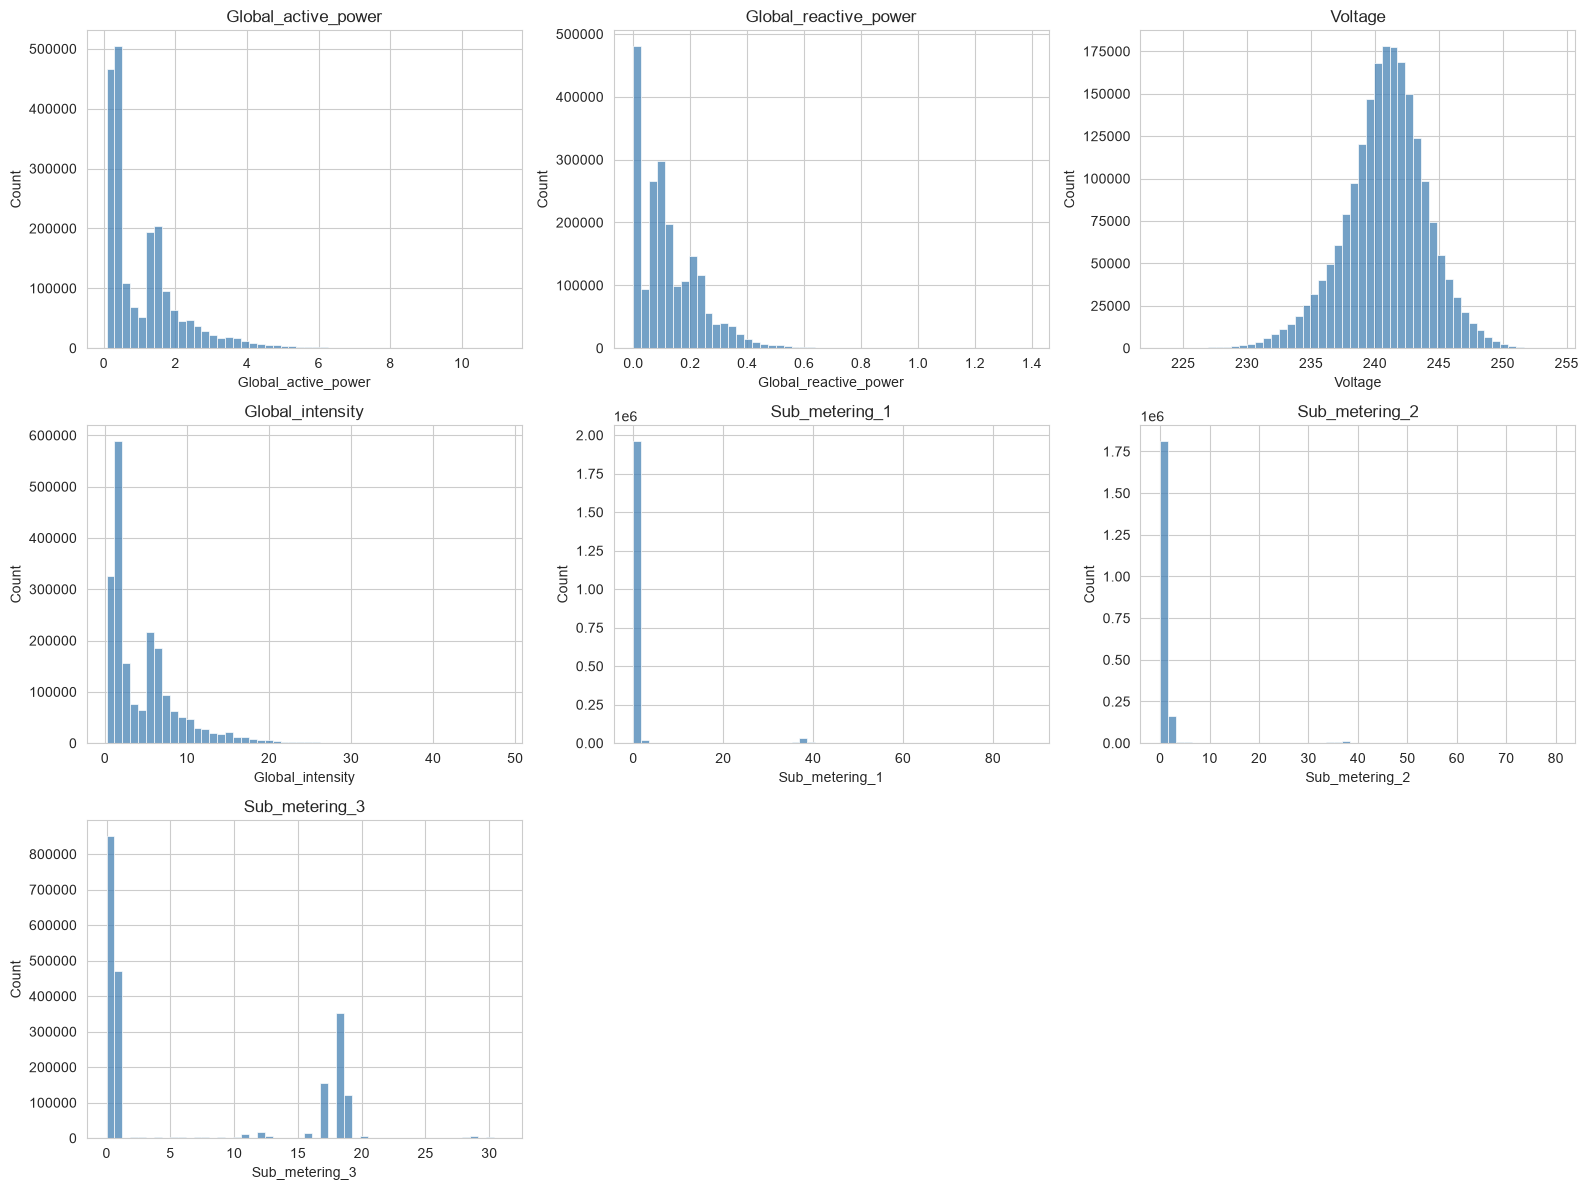

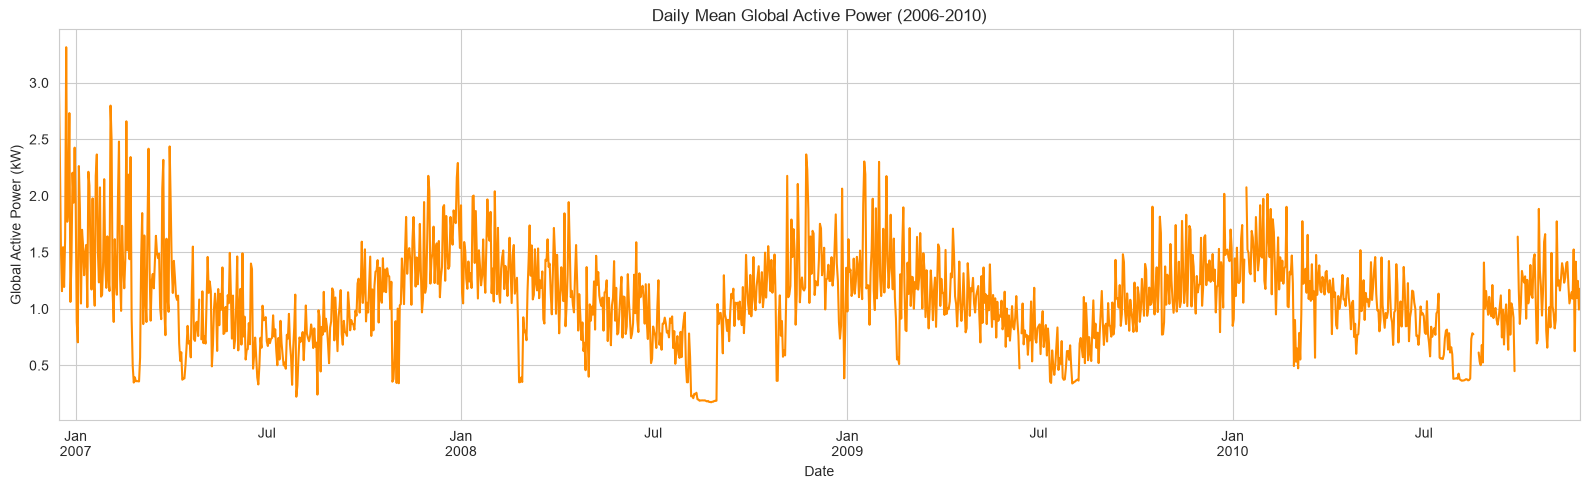


Number of distinct days with at least one missing timestamp: 82

Top 10 days by number of missing minutes:
Datetime
2010-08-20    1440
2009-06-14    1440
2010-09-27    1440
2010-09-26    1440
2010-08-18    1440
2007-04-29    1440
2010-01-13    1440
2010-08-19    1440
2010-08-21    1440
2007-04-28    1419
dtype: int64


In [5]:
# =========================================================
# STEP 5: Exploratory Data Analysis — Distributions & Time-Series Patterns
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---- 5.1 Descriptive statistics ----
print("Descriptive statistics:")
display(X.describe())

# ---- 5.2 Distribution histograms for each numeric variable ----
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.histplot(X[col].dropna(), bins=50, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

for j in range(len(X.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Charts/01_distributions_histograms.png", dpi=150)
plt.show()

# ---- 5.3 Daily mean Global_active_power over time (seasonality check) ----
daily_mean = X["Global_active_power"].resample("D").mean()

plt.figure(figsize=(16, 5))
daily_mean.plot(color="darkorange")
plt.title("Daily Mean Global Active Power (2006-2010)")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.tight_layout()
plt.savefig("Charts/02_daily_mean_active_power.png", dpi=150)
plt.show()

# ---- 5.4 Timing of missing values: are they clustered or scattered? ----
missing_mask = X.isna().any(axis=1)
missing_by_date = missing_mask.resample("D").sum()
missing_by_date = missing_by_date[missing_by_date > 0]

print(f"\nNumber of distinct days with at least one missing timestamp: {len(missing_by_date)}")
print("\nTop 10 days by number of missing minutes:")
print(missing_by_date.sort_values(ascending=False).head(10))

## Step 6: Missing Value Strategy — Analyzing Gap Structure

Before choosing an imputation method, we need to know the *shape* of our missing data, not just the total count. We already know 82 days are affected and several show a full 1,440-minute (24-hour) gap. This matters because:

- **Short gaps** (a few minutes to a couple hours) are safe to fill with time-based linear interpolation — consumption changes smoothly minute-to-minute, so this is a defensible estimate.
- **Long gaps** (near-full days) make interpolation meaningless — a straight line across 24 hours ignores the actual daily usage cycle (morning ramp-up, evening peak, overnight lull) and would fabricate a flat, unrealistic pattern.

So in this step we identify every contiguous block of missing timestamps and measure its length. This gap-length distribution is what will determine our imputation rule in the next step — likely a hybrid: linear interpolation for short gaps, and a seasonal/pattern-based fill (e.g., using the same weekday-and-time from a neighboring week) for long gaps.

We are still purely diagnostic here — no values get modified in this step.

In [6]:
# =========================================================
# STEP 6: Missing Value Strategy — Analyzing Gap Structure
# =========================================================

# ---- 6.1 Identify contiguous blocks of missing rows ----
is_missing = X.isna().any(axis=1)

# Assign a group ID that increments every time missingness status changes
block_id = (is_missing != is_missing.shift()).cumsum()

# Keep only the missing blocks, group by block_id, measure size and time span
missing_blocks = (
    X[is_missing]
    .groupby(block_id[is_missing])
    .apply(lambda g: pd.Series({
        "start": g.index.min(),
        "end": g.index.max(),
        "n_minutes": len(g)
    }))
    .reset_index(drop=True)
)

print(f"Total number of distinct missing gaps (contiguous blocks): {len(missing_blocks)}")
print(f"\nGap length summary (minutes):")
print(missing_blocks["n_minutes"].describe())

# ---- 6.2 Bucket gaps into short / medium / long ----
def bucket_gap(n):
    if n <= 60:
        return "short (<=1h)"
    elif n <= 360:
        return "medium (1-6h)"
    else:
        return "long (>6h)"

missing_blocks["bucket"] = missing_blocks["n_minutes"].apply(bucket_gap)

print("\nGap count and total minutes by bucket:")
bucket_summary = missing_blocks.groupby("bucket").agg(
    n_gaps=("n_minutes", "count"),
    total_minutes=("n_minutes", "sum")
)
display(bucket_summary)

# ---- 6.3 Show the 15 longest gaps ----
print("\n15 longest missing gaps:")
display(missing_blocks.sort_values("n_minutes", ascending=False).head(15))

Total number of distinct missing gaps (contiguous blocks): 71

Gap length summary (minutes):
count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
Name: n_minutes, dtype: float64

Gap count and total minutes by bucket:


,n_gaps,total_minutes
bucket,,
long (>6h),7,25538
medium (1-6h),2,153
short (<=1h),62,288



15 longest missing gaps:


,start,end,n_minutes,bucket
68,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,long (>6h)
69,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,long (>6h)
6,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,long (>6h)
49,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,long (>6h)
58,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,long (>6h)
62,2010-03-20 03:52:00,2010-03-21 13:38:00,2027,long (>6h)
51,2009-08-13 05:00:00,2009-08-13 19:50:00,891,long (>6h)
15,2007-07-15 16:49:00,2007-07-15 18:11:00,83,medium (1-6h)
38,2008-12-10 10:48:00,2008-12-10 11:57:00,70,medium (1-6h)
16,2007-07-15 18:21:00,2007-07-15 19:07:00,47,short (<=1h)


## Step 7: Hybrid Missing Value Imputation

Based on the gap analysis, we apply two different techniques depending on gap length, using a threshold of 6 hours to separate them:

**Short/medium gaps (≤ 6 hours, 64 gaps, 441 minutes total):**
Time-based linear interpolation (`method='time'`). Consumption changes smoothly minute-to-minute, so a straight-line estimate between two known points is a safe, standard approach for brief sensor dropouts.

**Long gaps (> 6 hours, 7 gaps, 25,538 minutes — 98% of all missing data):**
Weekly seasonal fill: for each missing timestamp, we substitute the value recorded exactly 7 days earlier at the same time-of-day (same weekday, same minute). Electricity usage is strongly weekly-cyclical (weekday routines repeat), so this preserves realistic daily peaks/troughs instead of flattening them. If the value 7 days prior is itself missing, we fall back to 7 days *after*. This is a well-established technique for seasonal time-series imputation and is far more defensible here than interpolation or a global mean fill.

We apply this per-column (all 7 numeric columns), then verify zero remaining `NaN`s before moving on. We'll also visually spot-check one of the long-gap periods afterward to confirm the fill looks realistic rather than artificially smooth or repetitive.

Short/medium gaps to interpolate: 64 (441 minutes)
Long gaps to seasonal-fill: 7 (25538 minutes)

Remaining missing values after imputation: 0


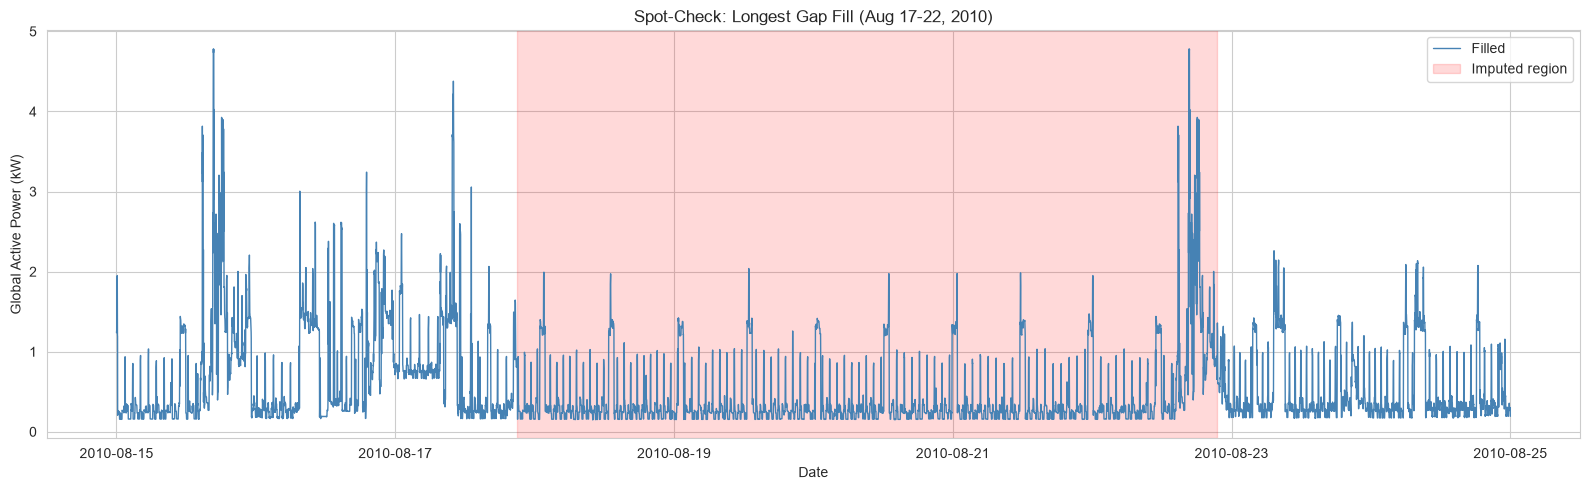

In [7]:
# =========================================================
# STEP 7: Hybrid Missing Value Imputation
# =========================================================

X_clean = X.copy()

# ---- 7.1 Re-identify missing blocks (same logic as Step 6) ----
is_missing = X_clean.isna().any(axis=1)
block_id = (is_missing != is_missing.shift()).cumsum()

missing_blocks = (
    X_clean[is_missing]
    .groupby(block_id[is_missing])
    .apply(lambda g: pd.Series({"start": g.index.min(), "end": g.index.max(), "n_minutes": len(g)}))
    .reset_index(drop=True)
)

GAP_THRESHOLD_MINUTES = 360  # 6 hours

long_gaps = missing_blocks[missing_blocks["n_minutes"] > GAP_THRESHOLD_MINUTES]
short_gaps = missing_blocks[missing_blocks["n_minutes"] <= GAP_THRESHOLD_MINUTES]

print(f"Short/medium gaps to interpolate: {len(short_gaps)} ({short_gaps['n_minutes'].sum()} minutes)")
print(f"Long gaps to seasonal-fill: {len(long_gaps)} ({long_gaps['n_minutes'].sum()} minutes)")

# ---- 7.2 Long gaps: weekly seasonal fill (same weekday/time, -7 days, fallback +7 days) ----
for _, row in long_gaps.iterrows():
    gap_index = X_clean.loc[row["start"]:row["end"]].index

    lookback = gap_index - pd.Timedelta(days=7)
    lookahead = gap_index + pd.Timedelta(days=7)

    for col in X_clean.columns:
        fill_values = X_clean[col].reindex(lookback).values
        # Fallback to +7 days wherever the -7 day value is also missing/unavailable
        fallback_values = X_clean[col].reindex(lookahead).values
        fill_values = np.where(pd.isna(fill_values), fallback_values, fill_values)
        X_clean.loc[gap_index, col] = fill_values

# ---- 7.3 Short/medium gaps (and any remaining stragglers): time-based linear interpolation ----
X_clean = X_clean.interpolate(method="time", limit_direction="both")

# ---- 7.4 Verify zero missing values remain ----
remaining_missing = X_clean.isna().sum().sum()
print(f"\nRemaining missing values after imputation: {remaining_missing}")

# ---- 7.5 Visual spot-check: the longest gap (Aug 17-22, 2010) ----
check_start = pd.Timestamp("2010-08-15")
check_end = pd.Timestamp("2010-08-25")

plt.figure(figsize=(16, 5))
plt.plot(X_clean.loc[check_start:check_end, "Global_active_power"], label="Filled", color="steelblue", linewidth=1)
plt.axvspan(pd.Timestamp("2010-08-17 21:02:00"), pd.Timestamp("2010-08-22 21:27:00"),
            color="red", alpha=0.15, label="Imputed region")
plt.title("Spot-Check: Longest Gap Fill (Aug 17-22, 2010)")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig("Charts/03_gap_fill_spotcheck.png", dpi=150)
plt.show()

## Step 8: Sanity-Checking the Imputed Region

The longest imputed gap (Aug 17–22, 2010) shows a lower, more repetitive consumption pattern than its surroundings. Before moving forward, we verify whether this is a plausible real-world scenario (e.g., a household vacation) rather than a fill artifact — since August is peak French holiday season, this is a reasonable hypothesis to test.

We check `Sub_metering_1` (kitchen) and `Sub_metering_2` (laundry room) during this window — near-zero activity in both would strongly support "nobody was home," which validates that our weekly seasonal fill correctly reflects a real recurring low-activity state in the source weeks, rather than an artificial flattening.

In [8]:
# =========================================================
# STEP 8: Sanity-Checking the Imputed Region
# =========================================================

gap_start = pd.Timestamp("2010-08-17 21:02:00")
gap_end = pd.Timestamp("2010-08-22 21:27:00")

gap_window = X_clean.loc[gap_start:gap_end]

print("Summary stats during the imputed gap (Aug 17-22, 2010):")
display(gap_window[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "Global_active_power"]].describe())

# Compare to the same week one week prior (source of the fill) and a typical week
prior_week = X_clean.loc[gap_start - pd.Timedelta(days=7): gap_end - pd.Timedelta(days=7)]
print("\nSame period, 7 days prior (fill source):")
display(prior_week[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "Global_active_power"]].describe())

Summary stats during the imputed gap (Aug 17-22, 2010):


,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power
count,7226.0,7226.000000,7226.000000,7226.000000
mean,0.0,0.885414,2.908663,0.431393
std,0.0,4.524185,5.631568,0.471204
min,0.0,0.000000,0.000000,0.150000
25%,0.0,0.000000,0.000000,0.180000
50%,0.0,0.000000,1.000000,0.254000
75%,0.0,1.000000,1.000000,0.342000
max,0.0,75.000000,30.000000,4.780000



Same period, 7 days prior (fill source):


,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power
count,7226.0,7226.000000,7226.000000,7226.000000
mean,0.0,0.885414,2.908663,0.431393
std,0.0,4.524185,5.631568,0.471204
min,0.0,0.000000,0.000000,0.150000
25%,0.0,0.000000,0.000000,0.180000
50%,0.0,0.000000,1.000000,0.254000
75%,0.0,1.000000,1.000000,0.342000
max,0.0,75.000000,30.000000,4.780000


## Step 9: Feature Engineering for Time-Series Regression

With a fully imputed, clean dataset, we now engineer features that give a regression model access to time-based patterns it can't infer from raw timestamps alone. Based on our EDA (clear daily and seasonal cycles), we'll create:

**Calendar/cyclical features:**
- `hour`, `day_of_week`, `month`, `is_weekend` — direct time components
- Cyclical encodings (`hour_sin`/`hour_cos`, `month_sin`/`month_cos`) — since hour 23 and hour 0 are actually adjacent, raw integer encoding would mislead a regression model into treating them as far apart. Sine/cosine encoding preserves that circularity.

**Lag features:**
- `Global_active_power` at *t-1* and *t-60* (1 minute ago, 1 hour ago) — since power consumption is highly autocorrelated minute-to-minute, recent history is one of the strongest predictors available.

**Rolling window features:**
- Rolling mean and rolling std of `Global_active_power` over a 60-minute window — captures recent trend/volatility, smoothing out minute-level noise while remaining responsive to real shifts (e.g., an appliance turning on).

**Derived feature from the documentation:**
- `unmetered_power` = `(Global_active_power*1000/60) - Sub_metering_1 - Sub_metering_2 - Sub_metering_3` — this is explicitly defined in the dataset's own notes as the energy used by equipment not captured by the three sub-meters (e.g., HVAC, water heater compressor cycles). It's a legitimate derived signal, not redundant with our target.

We compute lag/rolling features *after* imputation (correct order — otherwise NaN gaps would corrupt the rolling windows) and drop the resulting leading NaN rows created by the lag/rolling operations themselves (a small, unavoidable trade-off at the very start of the series).

In [9]:
# =========================================================
# STEP 9: Feature Engineering for Time-Series Regression
# =========================================================

df = X_clean.copy()

# ---- 9.1 Calendar features ----
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek  # Monday=0
df["month"] = df.index.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# ---- 9.2 Cyclical encodings ----
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# ---- 9.3 Lag features ----
df["gap_lag_1min"] = df["Global_active_power"].shift(1)
df["gap_lag_60min"] = df["Global_active_power"].shift(60)

# ---- 9.4 Rolling window features (using only past data, no leakage) ----
df["gap_roll_mean_60min"] = df["Global_active_power"].shift(1).rolling(window=60).mean()
df["gap_roll_std_60min"] = df["Global_active_power"].shift(1).rolling(window=60).std()

# ---- 9.5 Derived unmetered power feature (per dataset documentation) ----
df["unmetered_power"] = (
    (df["Global_active_power"] * 1000 / 60)
    - df["Sub_metering_1"] - df["Sub_metering_2"] - df["Sub_metering_3"]
)

# ---- 9.6 Drop leading rows with NaN from lag/rolling operations ----
before_rows = len(df)
df = df.dropna()
after_rows = len(df)
print(f"Dropped {before_rows - after_rows} leading rows due to lag/rolling window NaNs")
print(f"Final shape: {df.shape}")

# ---- 9.7 Preview engineered features ----
display(df.head(3))
print("\nAll columns:")
print(df.columns.tolist())

Dropped 60 leading rows due to lag/rolling window NaNs
Final shape: (2075199, 20)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,month_sin,month_cos,gap_lag_1min,gap_lag_60min,gap_roll_mean_60min,gap_roll_std_60min,unmetered_power
Datetime,,,,,,,,,,,,,,,,,,,,
2006-12-16 18:24:00,3.452,0.0,235.20,15.2,0.0,1.0,17.0,18,5,12,1,-1.0,-1.836970e-16,-2.449294e-16,1.0,2.926,4.216,4.103600,1.243131,39.533333
2006-12-16 18:25:00,4.870,0.0,233.74,20.8,0.0,1.0,17.0,18,5,12,1,-1.0,-1.836970e-16,-2.449294e-16,1.0,3.452,5.360,4.090867,1.245870,63.166667
2006-12-16 18:26:00,4.868,0.0,233.84,20.8,0.0,1.0,17.0,18,5,12,1,-1.0,-1.836970e-16,-2.449294e-16,1.0,4.870,5.374,4.082700,1.238996,63.133333



All columns:
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'gap_lag_1min', 'gap_lag_60min', 'gap_roll_mean_60min', 'gap_roll_std_60min', 'unmetered_power']


## Step 10: Feature Scaling

Our final preprocessing step before the dataset is regression-ready. A few deliberate decisions here:

**Which columns get scaled:**
Continuous numeric features (`Global_reactive_power`, `Voltage`, `Global_intensity`, `Sub_metering_1/2/3`, lag features, rolling features, `unmetered_power`). We exclude `Global_active_power` itself since it's our intended regression target and should stay in its natural, interpretable unit — scaling the target is a modeling-time decision, not a preprocessing one.

We also exclude features that are already bounded and meaningfully encoded: `hour_sin/cos`, `month_sin/cos` (already in [-1, 1]), and `is_weekend` (already binary). Scaling these again would be redundant and could distort their intended cyclical geometry.

**Which scaler:**
Recall from our EDA that most features (especially the sub-metering columns) are heavily right-skewed with a large mass at zero and a long tail of appliance spikes. A `StandardScaler` (mean/variance based) is sensitive to that skew and outlier tail — the "spike" values would dominate the variance calculation and compress the meaningful low-range variation. Instead, we use **`RobustScaler`**, which centers on the median and scales by the interquartile range (IQR). This is far more resistant to the skew and outliers we observed, and keeps the bulk of typical low-usage readings meaningfully spread out rather than crushed near zero.

We fit the scaler and save it alongside the cleaned data — critical for reproducibility, since any future prediction must be scaled with these exact same parameters, not refit.

In [10]:
# =========================================================
# STEP 10: Feature Scaling
# =========================================================

from sklearn.preprocessing import RobustScaler
import joblib

# ---- 10.1 Define columns to scale (exclude target + already-bounded features) ----
exclude_cols = [
    "Global_active_power",  # regression target — left unscaled
    "hour", "day_of_week", "month",  # raw versions superseded by cyclical encodings
    "hour_sin", "hour_cos", "month_sin", "month_cos",  # already bounded [-1, 1]
    "is_weekend"  # already binary
]

cols_to_scale = [c for c in df.columns if c not in exclude_cols]
print(f"Columns to scale ({len(cols_to_scale)}):")
print(cols_to_scale)

# ---- 10.2 Fit and apply RobustScaler ----
scaler = RobustScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# ---- 10.3 Confirm result ----
print("\nScaled data summary:")
display(df_scaled[cols_to_scale].describe().loc[["mean", "std", "min", "max"]])

# ---- 10.4 Save the fitted scaler for future reproducibility ----
joblib.dump(scaler, "Cleaned_Datasets/robust_scaler.pkl")
print("\nScaler saved to: Cleaned_Datasets/robust_scaler.pkl")

# ---- 10.5 Save the final model-ready dataset ----
final_path = "Cleaned_Datasets/household_power_consumption_model_ready.csv"
df_scaled.to_csv(final_path)
print(f"Final model-ready dataset saved to: {final_path}")
print(f"Final shape: {df_scaled.shape}")

Columns to scale (11):
['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'gap_lag_1min', 'gap_lag_60min', 'gap_roll_mean_60min', 'gap_roll_std_60min', 'unmetered_power']

Scaled data summary:


,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,gap_lag_1min,gap_lag_60min,gap_roll_mean_60min,gap_roll_std_60min,unmetered_power
mean,0.163153,-0.044717,0.403359,1.120948,1.295408,0.320742,0.403067,0.403136,0.237129,0.332891,0.578562
std,0.772305,0.833644,0.887661,6.150971,5.812204,0.496100,0.866922,0.867040,0.721028,0.756168,1.463448
min,-0.684932,-4.592784,-0.480000,0.000000,0.000000,-0.058824,-0.428571,-0.428571,-0.540586,-0.457824,-1.209184
max,8.835616,3.384021,9.160000,88.000000,80.000000,1.764706,8.640394,8.640394,5.033909,5.340985,18.265306



Scaler saved to: Cleaned_Datasets/robust_scaler.pkl
Final model-ready dataset saved to: Cleaned_Datasets/household_power_consumption_model_ready.csv
Final shape: (2075199, 20)


## Step 11: Train/Test Split — Respecting Temporal Order

Before any modeling, we split our data into training and test sets. This is the one step where time-series data demands a fundamentally different approach than typical tabular ML:

**Why we cannot use a random shuffled split:**
Our features include lag values (`gap_lag_1min`, `gap_lag_60min`) and rolling statistics (`gap_roll_mean_60min`, `gap_roll_std_60min`) — these are explicitly built from *past* values relative to each row. A random shuffle would let future information leak into the training set relative to test rows (and vice versa), and more fundamentally, evaluating a time-series model on randomly scattered points doesn't test what we actually care about: can this model predict power consumption it hasn't seen yet, going forward in time?

**Our approach:**
A simple **chronological split** — the earliest ~80% of the timeline becomes our training set, and the most recent ~20% becomes our test set. This mimics the real deployment scenario: train on history, predict on the future. We use `train_test_split` with `shuffle=False`, or equivalently just slice by index position, since our data is already sorted chronologically from Step 4.

We'll target an 80/20 split, which given our ~4-year span means training on roughly the first ~3.2 years and testing on the most recent ~9-10 months. We'll also visualize the split point on the daily-mean series to confirm it lands somewhere reasonable (not, say, splitting in the middle of a long missing-data-turned-imputed region).

Split point (first day of test set): 2010-02-11 15:43:00

Train set: 1660159 rows  (2006-12-16 18:24:00 to 2010-02-11 15:42:00)
Test set:  415040 rows  (2010-02-11 15:43:00 to 2010-11-26 21:02:00)

Train proportion: 80.00%
Test proportion:  20.00%


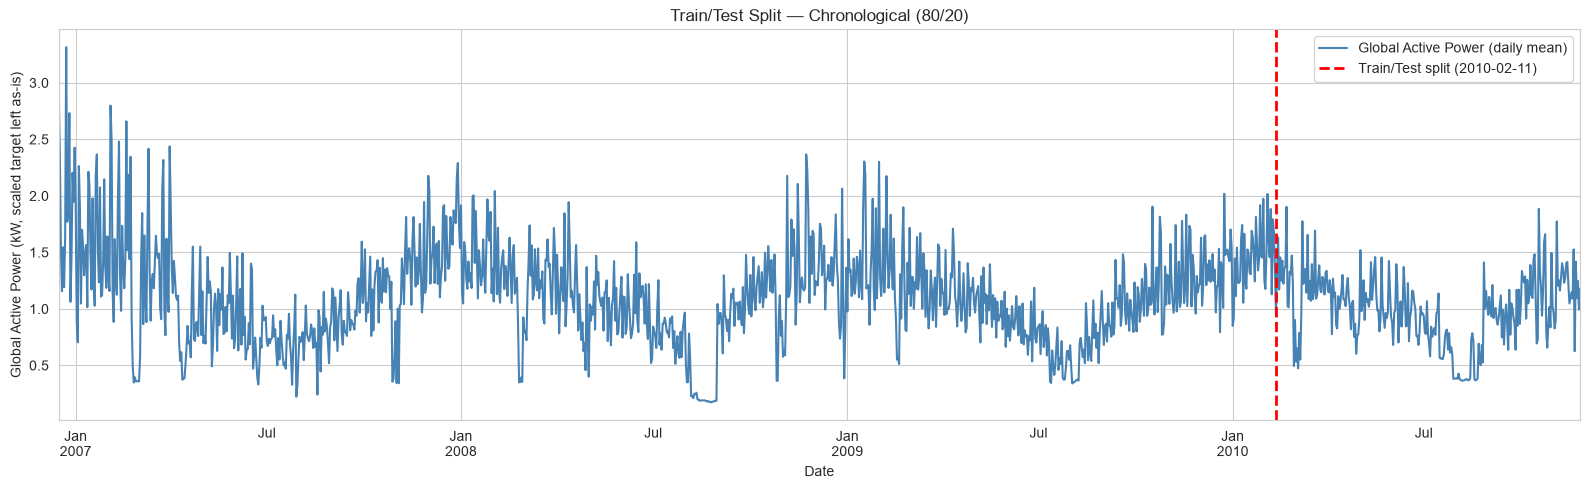

In [11]:
# =========================================================
# STEP 11: Train/Test Split — Respecting Temporal Order
# =========================================================

# ---- 11.1 Define target and features ----
TARGET = "Global_active_power"

X_features = df_scaled.drop(columns=[TARGET])
y_target = df_scaled[TARGET]

# ---- 11.2 Chronological 80/20 split (no shuffling) ----
split_idx = int(len(df_scaled) * 0.8)

X_train = X_features.iloc[:split_idx]
X_test = X_features.iloc[split_idx:]
y_train = y_target.iloc[:split_idx]
y_test = y_target.iloc[split_idx:]

split_date = df_scaled.index[split_idx]

print(f"Split point (first day of test set): {split_date}")
print(f"\nTrain set: {X_train.shape[0]} rows  ({X_train.index.min()} to {X_train.index.max()})")
print(f"Test set:  {X_test.shape[0]} rows  ({X_test.index.min()} to {X_test.index.max()})")
print(f"\nTrain proportion: {len(X_train) / len(df_scaled):.2%}")
print(f"Test proportion:  {len(X_test) / len(df_scaled):.2%}")

# ---- 11.3 Visualize the split point on daily mean series ----
daily_mean_full = df_scaled[TARGET].resample("D").mean()

plt.figure(figsize=(16, 5))
daily_mean_full.plot(color="steelblue", label="Global Active Power (daily mean)")
plt.axvline(split_date, color="red", linestyle="--", linewidth=2, label=f"Train/Test split ({split_date.date()})")
plt.title("Train/Test Split — Chronological (80/20)")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW, scaled target left as-is)")
plt.legend()
plt.tight_layout()
plt.savefig("Charts/04_train_test_split.png", dpi=150)
plt.show()

## Step 12: Baseline Regression Model — Linear Regression

Before reaching for anything sophisticated, we establish a baseline. This matters for two reasons: it tells us whether our engineered features carry real predictive signal at all, and it gives us a reference point that any more complex model must meaningfully beat to justify its added complexity.

We use **Linear Regression** as our baseline — no hyperparameters to tune, fully interpretable coefficients, and fast to fit even on ~1.66M training rows. Given that `gap_lag_1min` (the value one minute ago) is almost certainly going to dominate as a predictor — power consumption barely changes minute to minute — we expect this baseline to already perform quite well. That's actually useful information: it tells us how much of the "prediction problem" is trivially solved by recency alone, versus how much genuine signal comes from the calendar/seasonal features we engineered.

We'll evaluate using three complementary metrics:
- **MAE** (Mean Absolute Error) — directly interpretable in kW, easy to explain to a non-technical audience
- **RMSE** (Root Mean Squared Error) — penalizes large errors more, useful since appliance spikes are exactly the kind of error we care about catching
- **R²** — proportion of variance explained, standard baseline comparison metric

We fit only on the training set and evaluate strictly on the held-out chronological test set — no peeking.

Model fit in 1.19 seconds

Baseline Linear Regression — Test Set Performance:
  MAE:  0.0000 kW
  RMSE: 0.0000 kW
  R²:   1.0000

Top 10 features by absolute coefficient magnitude:


,feature,coefficient
5,Sub_metering_3,1.020000e+00
18,unmetered_power,3.920000e-01
3,Sub_metering_1,6.000000e-02
4,Sub_metering_2,6.000000e-02
0,Global_reactive_power,-1.876571e-14
2,Global_intensity,1.644171e-14
16,gap_roll_mean_60min,6.279699e-16
11,hour_cos,5.377643e-16
14,gap_lag_1min,-4.891920e-16
1,Voltage,4.440892e-16


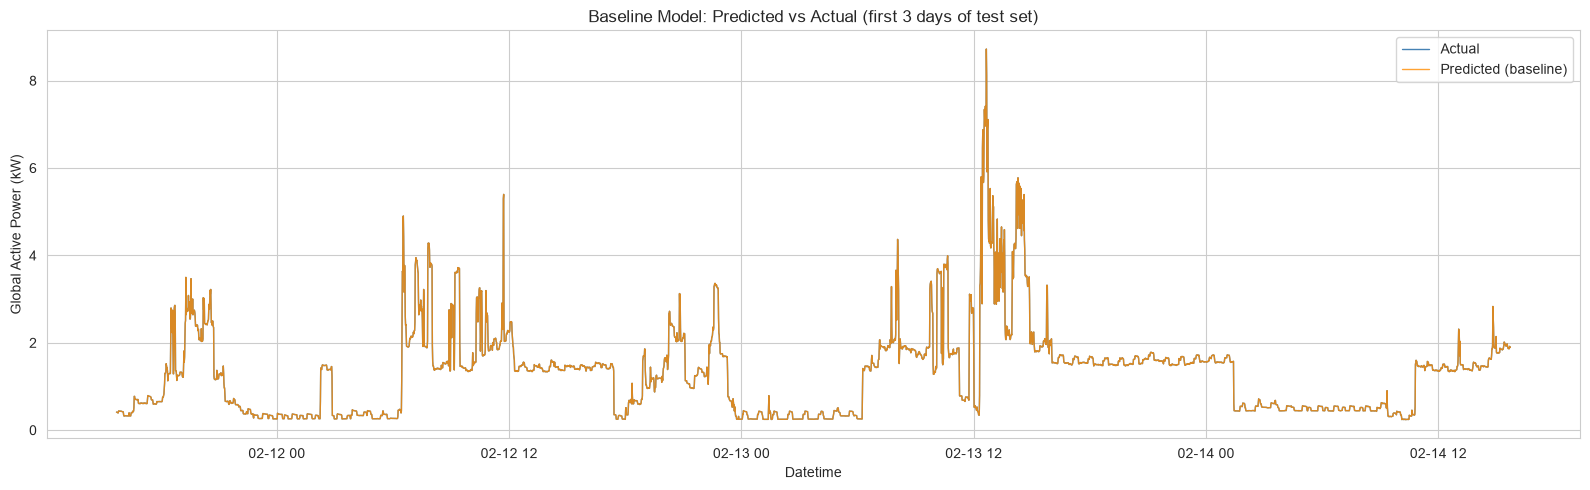

In [12]:
# =========================================================
# STEP 12: Baseline Regression Model — Linear Regression
# =========================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# ---- 12.1 Fit baseline model ----
baseline_model = LinearRegression()

start_time = time.time()
baseline_model.fit(X_train, y_train)
fit_time = time.time() - start_time

print(f"Model fit in {fit_time:.2f} seconds")

# ---- 12.2 Predict on held-out test set ----
y_pred_baseline = baseline_model.predict(X_test)

# ---- 12.3 Evaluate ----
mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2 = r2_score(y_test, y_pred_baseline)

print("\nBaseline Linear Regression — Test Set Performance:")
print(f"  MAE:  {mae:.4f} kW")
print(f"  RMSE: {rmse:.4f} kW")
print(f"  R²:   {r2:.4f}")

# ---- 12.4 Inspect coefficients to see which features dominate ----
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": baseline_model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nTop 10 features by absolute coefficient magnitude:")
display(coef_df.head(10))

# ---- 12.5 Visual: predicted vs actual over a sample window (first 3 days of test set) ----
sample_start = X_test.index.min()
sample_end = sample_start + pd.Timedelta(days=3)

plt.figure(figsize=(16, 5))
plt.plot(y_test.loc[sample_start:sample_end], label="Actual", color="steelblue", linewidth=1)
plt.plot(pd.Series(y_pred_baseline, index=X_test.index).loc[sample_start:sample_end],
          label="Predicted (baseline)", color="darkorange", linewidth=1, alpha=0.8)
plt.title("Baseline Model: Predicted vs Actual (first 3 days of test set)")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig("Charts/05_baseline_predicted_vs_actual.png", dpi=150)
plt.show()

## Step 13: Fixing Data Leakage — Removing `unmetered_power`

Our Step 12 baseline achieved a perfect R² of 1.0, which is not a real result — it's data leakage. `unmetered_power` was engineered directly from `Global_active_power` via the formula in the dataset's own documentation:

`unmetered_power = (Global_active_power * 1000/60) - Sub_metering_1 - Sub_metering_2 - Sub_metering_3`

This means `Global_active_power` can be exactly reconstructed via simple algebra from `unmetered_power` + the three sub-metering columns. The "model" wasn't predicting anything — it was solving an equation we accidentally handed it.

**The fix:** drop `unmetered_power` entirely from our feature set. It was a reasonable idea in isolation (it does represent real information — unmetered appliance load), but it can never be used as a *predictor* of `Global_active_power` specifically, since it's mathematically derived from that exact target. We keep the three sub-metering columns, since although they're used in the leaky formula, they are independently measured raw sensor readings, not derived from the target — using them as predictors is legitimate.

We rebuild the train/test split without this column and re-run the baseline to get a trustworthy result.

Dropped leaky feature(s): ['unmetered_power']
Remaining feature count: 18
Remaining features: ['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'gap_lag_1min', 'gap_lag_60min', 'gap_roll_mean_60min', 'gap_roll_std_60min']

Corrected Baseline Linear Regression — Test Set Performance:
  MAE:  0.0238 kW
  RMSE: 0.0386 kW
  R²:   0.9981

Top 10 features by absolute coefficient magnitude (corrected):


,feature,coefficient
2,Global_intensity,1.160148
5,Sub_metering_3,0.038278
0,Global_reactive_power,-0.023301
14,gap_lag_1min,0.021625
1,Voltage,0.014426
16,gap_roll_mean_60min,0.008966
13,month_cos,0.004669
17,gap_roll_std_60min,-0.004341
12,month_sin,0.004285
11,hour_cos,0.002992


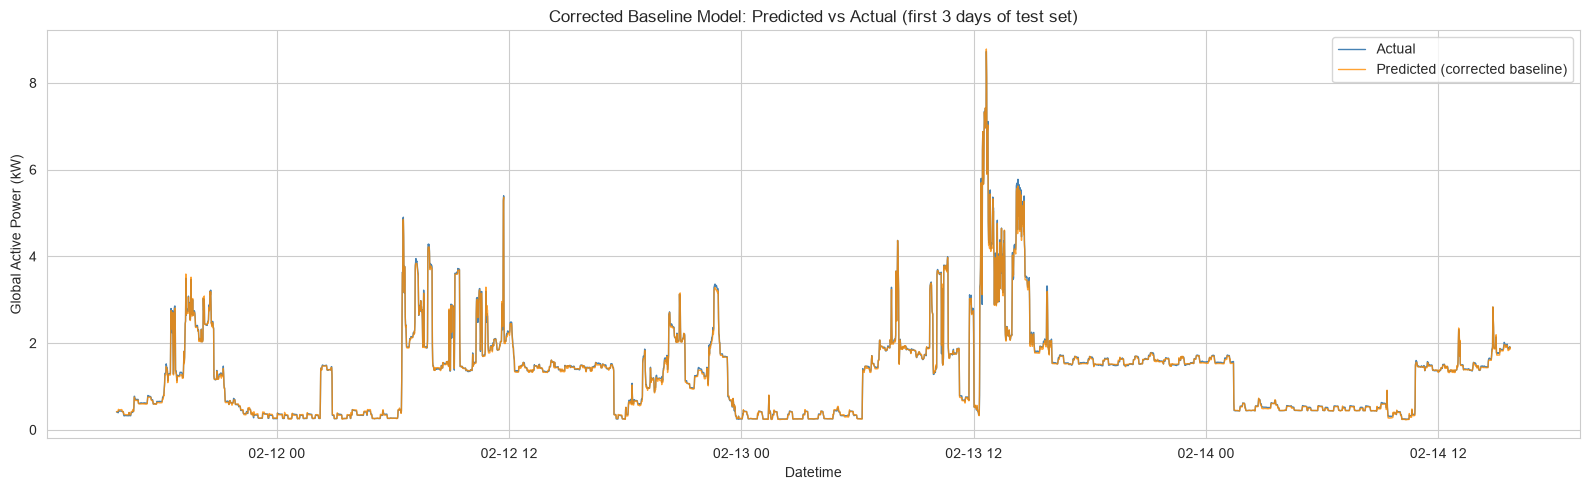

In [13]:
# =========================================================
# STEP 13: Fixing Data Leakage — Removing 'unmetered_power'
# =========================================================

LEAKY_FEATURES = ["unmetered_power"]

X_train_fixed = X_train.drop(columns=LEAKY_FEATURES)
X_test_fixed = X_test.drop(columns=LEAKY_FEATURES)

print(f"Dropped leaky feature(s): {LEAKY_FEATURES}")
print(f"Remaining feature count: {X_train_fixed.shape[1]}")
print(f"Remaining features: {X_train_fixed.columns.tolist()}")

# ---- 13.1 Re-fit baseline Linear Regression without the leaky feature ----
baseline_model_fixed = LinearRegression()
baseline_model_fixed.fit(X_train_fixed, y_train)

y_pred_fixed = baseline_model_fixed.predict(X_test_fixed)

mae_fixed = mean_absolute_error(y_test, y_pred_fixed)
rmse_fixed = np.sqrt(mean_squared_error(y_test, y_pred_fixed))
r2_fixed = r2_score(y_test, y_pred_fixed)

print("\nCorrected Baseline Linear Regression — Test Set Performance:")
print(f"  MAE:  {mae_fixed:.4f} kW")
print(f"  RMSE: {rmse_fixed:.4f} kW")
print(f"  R²:   {r2_fixed:.4f}")

# ---- 13.2 Inspect coefficients again ----
coef_df_fixed = pd.DataFrame({
    "feature": X_train_fixed.columns,
    "coefficient": baseline_model_fixed.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nTop 10 features by absolute coefficient magnitude (corrected):")
display(coef_df_fixed.head(10))

# ---- 13.3 Visual: predicted vs actual over the same 3-day sample window ----
plt.figure(figsize=(16, 5))
plt.plot(y_test.loc[sample_start:sample_end], label="Actual", color="steelblue", linewidth=1)
plt.plot(pd.Series(y_pred_fixed, index=X_test_fixed.index).loc[sample_start:sample_end],
          label="Predicted (corrected baseline)", color="darkorange", linewidth=1, alpha=0.8)
plt.title("Corrected Baseline Model: Predicted vs Actual (first 3 days of test set)")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig("Charts/06_corrected_baseline_predicted_vs_actual.png", dpi=150)
plt.show()

## Step 14: Refining for a True Forecasting Setup — Dropping Simultaneous-Measurement Features

Per the confirmed use case (forecasting future power draw), we drop `Global_intensity` and `Global_reactive_power` — both are physically near-deterministic functions of `Global_active_power`, measured *simultaneously* rather than knowable in advance, so keeping them would make our "prediction" trivial rather than genuine forecasting.

**One more honest flag before we proceed:** `Voltage` and `Sub_metering_1/2/3` are *also* simultaneous readings — measured at the same instant as our target, not available ahead of time in a real forecasting deployment. Strictly speaking, a genuine forecasting model should only use information knowable *before* the prediction timestamp: our lag features, rolling statistics, and calendar features qualify; raw simultaneous sensor readings do not. 

For this step we're removing only the two columns you confirmed, since `Voltage` and the sub-metering columns are weaker, less deterministic predictors than `Global_intensity` and don't reproduce the near-perfect-score issue — but this is a scope decision worth revisiting. If the ultimate deployment target is "predict power consumption N minutes/hours ahead using no live readings at all," we'd need a follow-up step to drop those too and re-lag the sub-metering columns instead. Flagging this now so it's not a surprise later.

We retrain the baseline on this reduced, forecasting-appropriate feature set and re-evaluate.

Dropped: ['Global_intensity', 'Global_reactive_power']
Remaining feature count: 16
Remaining features: ['Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'gap_lag_1min', 'gap_lag_60min', 'gap_roll_mean_60min', 'gap_roll_std_60min']

Forecasting-Ready Baseline — Test Set Performance:
  MAE:  0.0961 kW
  RMSE: 0.1951 kW
  R²:   0.9516

Top 10 features by absolute coefficient magnitude:


,feature,coefficient
12,gap_lag_1min,0.931510
3,Sub_metering_3,0.211263
14,gap_roll_mean_60min,0.083396
11,month_cos,0.055030
0,Voltage,-0.054806
9,hour_cos,0.035837
10,month_sin,0.031504
15,gap_roll_std_60min,-0.017827
1,Sub_metering_1,0.016953
2,Sub_metering_2,0.015385


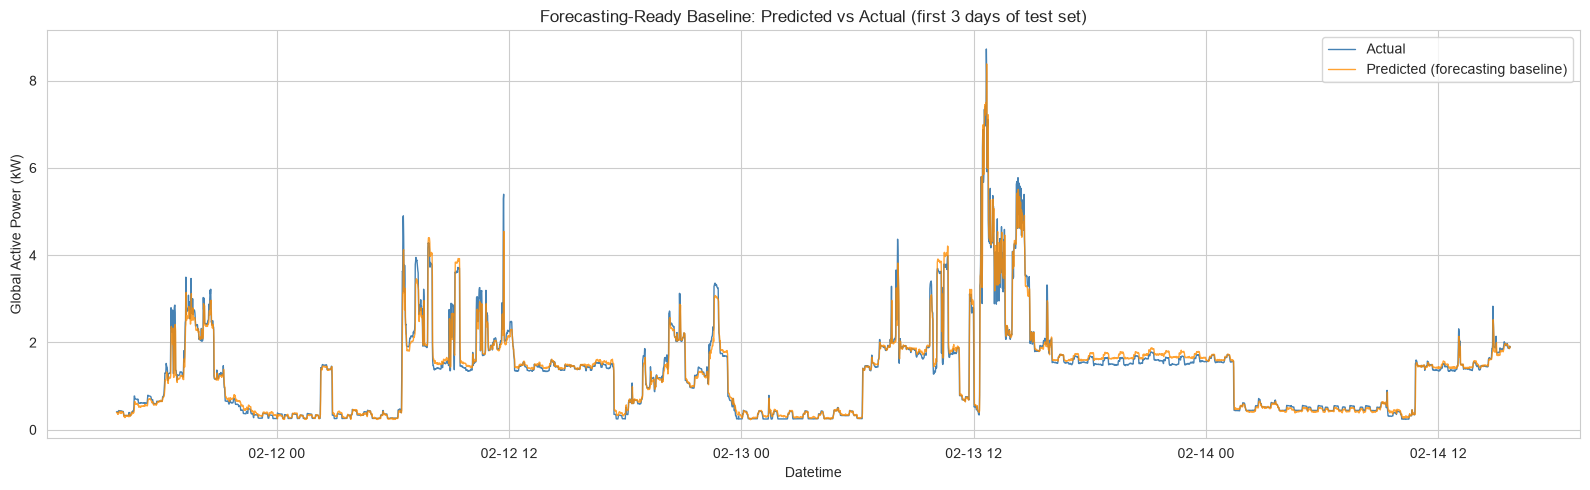

In [14]:
# =========================================================
# STEP 14: Refining for a True Forecasting Setup
# =========================================================

SIMULTANEOUS_FEATURES = ["Global_intensity", "Global_reactive_power"]

X_train_forecast = X_train_fixed.drop(columns=SIMULTANEOUS_FEATURES)
X_test_forecast = X_test_fixed.drop(columns=SIMULTANEOUS_FEATURES)

print(f"Dropped: {SIMULTANEOUS_FEATURES}")
print(f"Remaining feature count: {X_train_forecast.shape[1]}")
print(f"Remaining features: {X_train_forecast.columns.tolist()}")

# ---- 14.1 Re-fit baseline Linear Regression on the forecasting-appropriate feature set ----
baseline_model_forecast = LinearRegression()
baseline_model_forecast.fit(X_train_forecast, y_train)

y_pred_forecast = baseline_model_forecast.predict(X_test_forecast)

mae_forecast = mean_absolute_error(y_test, y_pred_forecast)
rmse_forecast = np.sqrt(mean_squared_error(y_test, y_pred_forecast))
r2_forecast = r2_score(y_test, y_pred_forecast)

print("\nForecasting-Ready Baseline — Test Set Performance:")
print(f"  MAE:  {mae_forecast:.4f} kW")
print(f"  RMSE: {rmse_forecast:.4f} kW")
print(f"  R²:   {r2_forecast:.4f}")

# ---- 14.2 Inspect coefficients ----
coef_df_forecast = pd.DataFrame({
    "feature": X_train_forecast.columns,
    "coefficient": baseline_model_forecast.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nTop 10 features by absolute coefficient magnitude:")
display(coef_df_forecast.head(10))

# ---- 14.3 Visual: predicted vs actual over the same 3-day sample window ----
plt.figure(figsize=(16, 5))
plt.plot(y_test.loc[sample_start:sample_end], label="Actual", color="steelblue", linewidth=1)
plt.plot(pd.Series(y_pred_forecast, index=X_test_forecast.index).loc[sample_start:sample_end],
          label="Predicted (forecasting baseline)", color="darkorange", linewidth=1, alpha=0.8)
plt.title("Forecasting-Ready Baseline: Predicted vs Actual (first 3 days of test set)")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig("Charts/07_forecasting_baseline_predicted_vs_actual.png", dpi=150)
plt.show()

## Step 15: Strict Forecasting Feature Set — Removing All Simultaneous Readings

To fully close the leakage risk, we remove the remaining simultaneous-measurement features — `Voltage`, `Sub_metering_1`, `Sub_metering_2`, `Sub_metering_3` — from our predictors. All four are recorded by the smart meter at the *same instant* as our target, `Global_active_power`. In a genuine forecasting deployment (predicting consumption ahead of time), none of these would be available for the timestamp we're trying to predict — only history (lags, rolling stats) and calendar information would be knowable in advance.

This leaves us with a feature set built entirely from information available strictly *before* the prediction timestamp:
- Calendar/cyclical: `hour`, `day_of_week`, `month`, `is_weekend`, `hour_sin/cos`, `month_sin/cos`
- Lag features: `gap_lag_1min`, `gap_lag_60min`
- Rolling features: `gap_roll_mean_60min`, `gap_roll_std_60min`

This is a stricter, more honest test of genuine forecasting ability. We expect performance to drop somewhat from our previous R² of 0.952, since we're removing real (if simultaneous) signal — that drop is expected and healthy, not a failure. It tells us the true ceiling of what's predictable from history and calendar alone, which is the number that actually matters for a deployed forecasting system.

We re-fit Linear Regression one more time on this fully clean feature set to establish our final, trustworthy baseline before moving to Random Forest.

Dropped: ['Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Final feature count: 12
Final features: ['hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'gap_lag_1min', 'gap_lag_60min', 'gap_roll_mean_60min', 'gap_roll_std_60min']

Strict Forecasting Baseline — Test Set Performance:
  MAE:  0.0834 kW
  RMSE: 0.2177 kW
  R²:   0.9398

Comparison:


,Model,MAE,RMSE,R2
0,With simultaneous features (Step 14),0.096121,0.195123,0.951600
1,Strict forecasting (Step 15),0.083357,0.217660,0.939774



Feature coefficients (strict model):


,feature,coefficient
8,gap_lag_1min,1.139912
10,gap_roll_mean_60min,0.064264
9,gap_lag_60min,-0.007194
7,month_cos,0.006145
11,gap_roll_std_60min,-0.005972
5,hour_cos,-0.005363
3,is_weekend,0.005350
6,month_sin,0.004889
0,hour,0.000801
4,hour_sin,0.000781


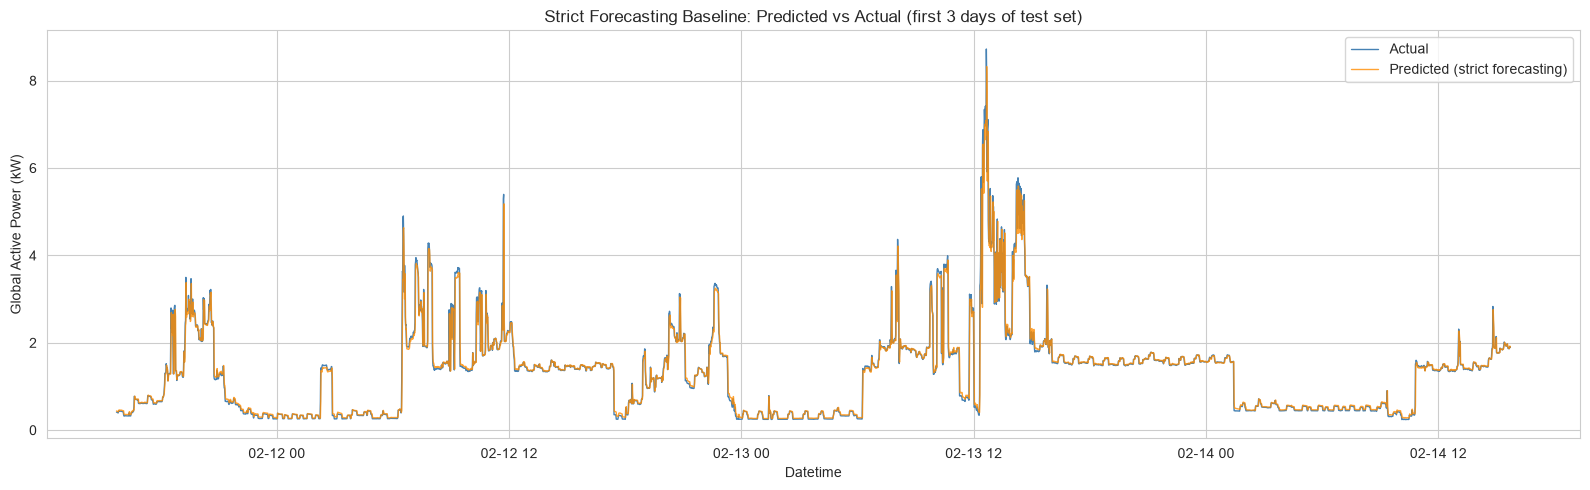


Strict train/test sets saved to Cleaned_Datasets/ for use in Step 16 (Random Forest)


In [15]:
# =========================================================
# STEP 15: Strict Forecasting Feature Set
# =========================================================

REMAINING_SIMULTANEOUS = ["Voltage", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]

X_train_strict = X_train_forecast.drop(columns=REMAINING_SIMULTANEOUS)
X_test_strict = X_test_forecast.drop(columns=REMAINING_SIMULTANEOUS)

print(f"Dropped: {REMAINING_SIMULTANEOUS}")
print(f"Final feature count: {X_train_strict.shape[1]}")
print(f"Final features: {X_train_strict.columns.tolist()}")

# ---- 15.1 Re-fit Linear Regression on the strict feature set ----
baseline_model_strict = LinearRegression()
baseline_model_strict.fit(X_train_strict, y_train)

y_pred_strict = baseline_model_strict.predict(X_test_strict)

mae_strict = mean_absolute_error(y_test, y_pred_strict)
rmse_strict = np.sqrt(mean_squared_error(y_test, y_pred_strict))
r2_strict = r2_score(y_test, y_pred_strict)

print("\nStrict Forecasting Baseline — Test Set Performance:")
print(f"  MAE:  {mae_strict:.4f} kW")
print(f"  RMSE: {rmse_strict:.4f} kW")
print(f"  R²:   {r2_strict:.4f}")

# ---- 15.2 Compare against the previous (less strict) baseline ----
comparison = pd.DataFrame({
    "Model": ["With simultaneous features (Step 14)", "Strict forecasting (Step 15)"],
    "MAE": [mae_forecast, mae_strict],
    "RMSE": [rmse_forecast, rmse_strict],
    "R2": [r2_forecast, r2_strict]
})
print("\nComparison:")
display(comparison)

# ---- 15.3 Coefficients ----
coef_df_strict = pd.DataFrame({
    "feature": X_train_strict.columns,
    "coefficient": baseline_model_strict.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nFeature coefficients (strict model):")
display(coef_df_strict)

# ---- 15.4 Visual: predicted vs actual, same 3-day window ----
plt.figure(figsize=(16, 5))
plt.plot(y_test.loc[sample_start:sample_end], label="Actual", color="steelblue", linewidth=1)
plt.plot(pd.Series(y_pred_strict, index=X_test_strict.index).loc[sample_start:sample_end],
          label="Predicted (strict forecasting)", color="darkorange", linewidth=1, alpha=0.8)
plt.title("Strict Forecasting Baseline: Predicted vs Actual (first 3 days of test set)")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig("Charts/08_strict_forecasting_predicted_vs_actual.png", dpi=150)
plt.show()

# ---- 15.5 Persist this feature set for the next model (Random Forest) ----
X_train_strict.to_csv("Cleaned_Datasets/X_train_strict.csv")
X_test_strict.to_csv("Cleaned_Datasets/X_test_strict.csv")
y_train.to_csv("Cleaned_Datasets/y_train.csv")
y_test.to_csv("Cleaned_Datasets/y_test.csv")
print("\nStrict train/test sets saved to Cleaned_Datasets/ for use in Step 16 (Random Forest)")

## Step 16: Random Forest Regression — Capturing Nonlinear Patterns

Our linear baseline plateaued at R² = 0.940, with a clear structural limitation: calendar features (hour, month, weekend) showed near-zero linear coefficients despite our EDA clearly showing real hour-of-day and seasonal effects on consumption. This is the classic signature of a **nonlinear relationship** — e.g., consumption doesn't rise *linearly* through the day, it jumps at specific hours (morning routine, evening peak) and plateaus overnight. A linear model can't exploit that shape no matter how good the feature is.

**Random Forest Regression** is a natural next step:
- It captures nonlinear relationships and interaction effects automatically (e.g., "hour=18 AND is_weekend=1" can have a very different effect than either alone) — something linear regression cannot do without manual interaction terms.
- It's an ensemble of decision trees, which handles the sharp, threshold-like jumps we saw in the actual-vs-predicted plots (appliance switch-on events) far better than a smooth linear function.
- It requires no feature scaling to function correctly (tree splits are scale-invariant) — though we'll keep using our already-scaled data for consistency, since it does no harm.

**Key parameters we're setting deliberately, not leaving as defaults:**
- `n_estimators=100` — a reasonable balance of accuracy vs. training time for ~1.66M rows; we can increase later if needed.
- `max_depth=15` — unconstrained trees on a dataset this size risk overfitting to noise (memorizing individual minutes) and become very slow; capping depth keeps trees generalizable.
- `min_samples_leaf=5` — prevents leaves that fit to single noisy observations.
- `n_jobs=-1` — parallelize across all available CPU cores, since Random Forest training is easily parallelizable and this dataset is large.
- `random_state=42` — reproducibility.

We evaluate with the same three metrics as before (MAE, RMSE, R²) for a direct, apples-to-apples comparison against our Step 15 linear baseline.

Random Forest fit in 316.9 seconds

Random Forest — Test Set Performance:
  MAE:  0.0805 kW
  RMSE: 0.2153 kW
  R²:   0.9411

Model comparison:


,Model,MAE,RMSE,R2
0,Linear Regression (Step 15),0.083357,0.217660,0.939774
1,Random Forest (Step 16),0.080470,0.215301,0.941072



Feature importances:


,feature,importance
8,gap_lag_1min,0.986846
10,gap_roll_mean_60min,0.003265
11,gap_roll_std_60min,0.003211
9,gap_lag_60min,0.002098
4,hour_sin,0.000818
0,hour,0.000759
5,hour_cos,0.000681
7,month_cos,0.000669
1,day_of_week,0.000604
2,month,0.000555


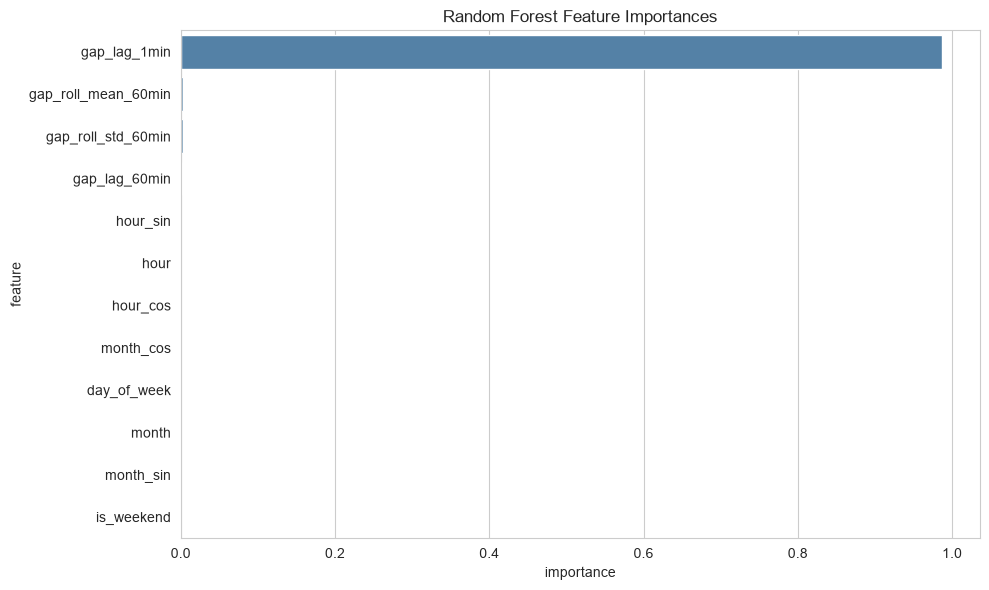

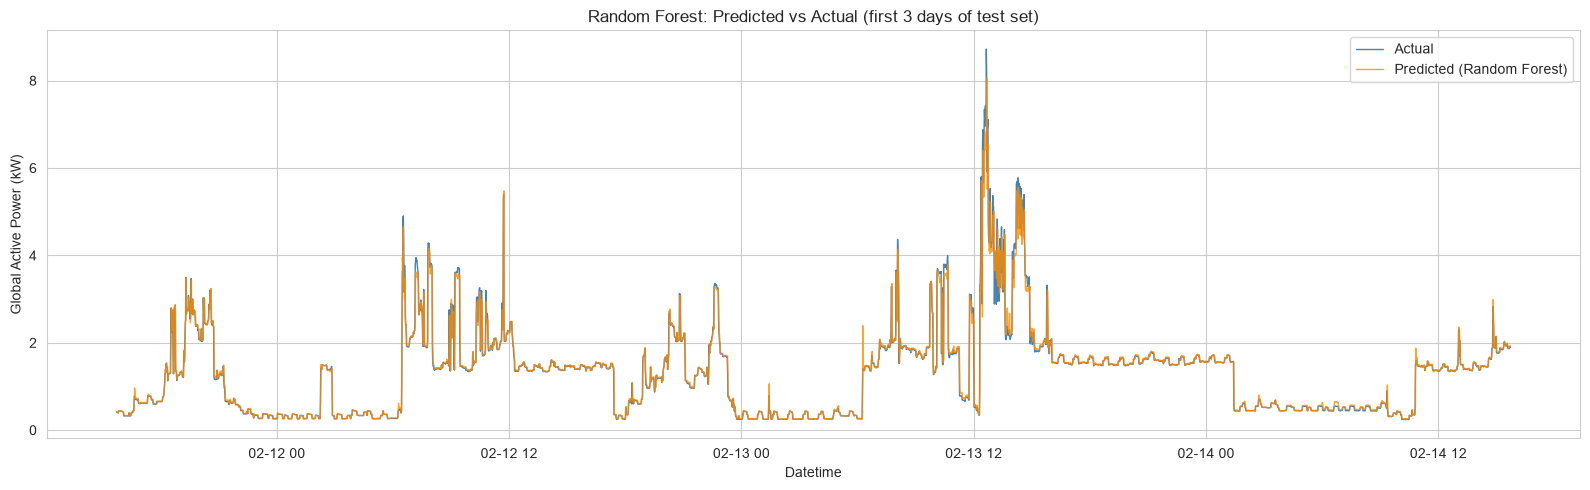

In [16]:
# =========================================================
# STEP 16: Random Forest Regression
# =========================================================

from sklearn.ensemble import RandomForestRegressor
import time

# ---- 16.1 Fit Random Forest ----
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
rf_model.fit(X_train_strict, y_train)
fit_time = time.time() - start_time

print(f"Random Forest fit in {fit_time:.1f} seconds")

# ---- 16.2 Predict on held-out test set ----
y_pred_rf = rf_model.predict(X_test_strict)

# ---- 16.3 Evaluate ----
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest — Test Set Performance:")
print(f"  MAE:  {mae_rf:.4f} kW")
print(f"  RMSE: {rmse_rf:.4f} kW")
print(f"  R²:   {r2_rf:.4f}")

# ---- 16.4 Direct comparison against the linear baseline ----
comparison_rf = pd.DataFrame({
    "Model": ["Linear Regression (Step 15)", "Random Forest (Step 16)"],
    "MAE": [mae_strict, mae_rf],
    "RMSE": [rmse_strict, rmse_rf],
    "R2": [r2_strict, r2_rf]
})
print("\nModel comparison:")
display(comparison_rf)

# ---- 16.5 Feature importances ----
importance_df = pd.DataFrame({
    "feature": X_train_strict.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature importances:")
display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="steelblue")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.savefig("Charts/09_rf_feature_importances.png", dpi=150)
plt.show()

# ---- 16.6 Visual: predicted vs actual, same 3-day window ----
plt.figure(figsize=(16, 5))
plt.plot(y_test.loc[sample_start:sample_end], label="Actual", color="steelblue", linewidth=1)
plt.plot(pd.Series(y_pred_rf, index=X_test_strict.index).loc[sample_start:sample_end],
          label="Predicted (Random Forest)", color="darkorange", linewidth=1, alpha=0.8)
plt.title("Random Forest: Predicted vs Actual (first 3 days of test set)")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig("Charts/10_rf_predicted_vs_actual.png", dpi=150)
plt.show()

## Step 17: Reframing as a 60-Minute-Ahead Forecast

Our 1-minute-ahead task was dominated by persistence (`gap_lag_1min` = 98.7% importance) — not a very realistic or actionable forecasting problem in practice. A more useful real-world horizon is **60 minutes ahead**: enough lead time to matter for demand-response decisions or load-shifting, while still being short enough to remain genuinely predictable from recent history and time-of-day patterns.

**What changes:**
- **Target**: instead of predicting `Global_active_power` at the current timestamp, we predict it **60 minutes into the future** — we shift the target column backward by 60 rows (`shift(-60)`), so each row's target becomes "what will consumption be an hour from now."
- **Features stay exactly the same** (`gap_lag_1min`, `gap_lag_60min`, rolling stats, calendar features) — all still computed from information available *up to and including* the current timestamp `t`. This is the correct causal setup: predicting `y(t+60)` using only features known at `t`.
- **Row trimming**: the last 60 rows of both train and test sets will have no valid future target (nothing 60 minutes past the end of our data), so we drop those trailing rows from each set independently — this keeps train and test still cleanly separated at our original chronological split point, no leakage introduced.

**What we expect to see:** `gap_lag_1min` should become a much weaker predictor at this horizon — a lot can change electrically in an hour — and we'd expect calendar/time-of-day features and the rolling mean to become meaningfully more important, since they capture the *general regime* (e.g., "it's evening, expect elevated usage") rather than the exact current reading. This is also where Random Forest's nonlinear capacity should have a real chance to outperform Linear Regression, unlike the 1-minute case.

We rebuild both models (Linear Regression and Random Forest) on this new target for a fair before/after comparison against our 1-minute-ahead results.

Dropped 0 trailing rows from train (no future target available)
Dropped 60 trailing rows from test (no future target available)

Train shape: (1660159, 12)
Test shape:  (414980, 12)

Random Forest fit in 283.4 seconds

Full comparison across horizons and models:


,Model,MAE,RMSE,R2
0,Linear Regression (1-min ahead),0.083357,0.217660,0.939774
1,Random Forest (1-min ahead),0.080470,0.215301,0.941072
2,Linear Regression (60-min ahead),0.544056,0.774726,0.237057
3,Random Forest (60-min ahead),0.498777,0.742340,0.299511



Random Forest feature importances (60-min-ahead):


,feature,importance
8,gap_lag_1min,0.458559
10,gap_roll_mean_60min,0.100429
4,hour_sin,0.086430
11,gap_roll_std_60min,0.074656
5,hour_cos,0.067928
1,day_of_week,0.046994
9,gap_lag_60min,0.043027
7,month_cos,0.037717
0,hour,0.031962
6,month_sin,0.022838


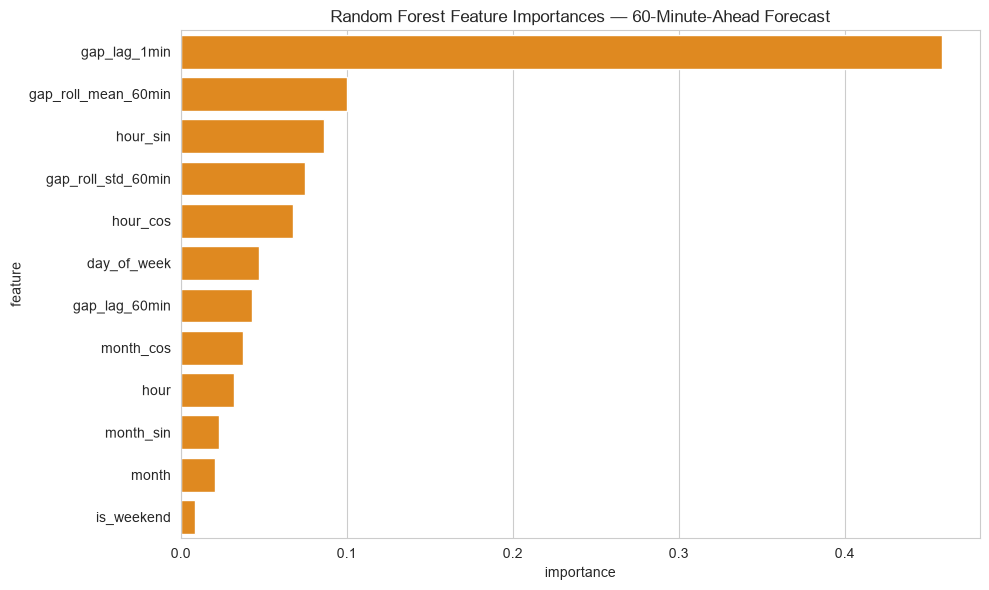

In [17]:
# =========================================================
# STEP 17: Reframing as a 60-Minute-Ahead Forecast
# =========================================================

HORIZON = 60  # minutes ahead

# ---- 17.1 Build the shifted target (future value, 60 minutes ahead) ----
y_full_60 = df_scaled["Global_active_power"].shift(-HORIZON)

# Align to the same feature sets we already built (strict, forecasting-safe features)
y_train_60 = y_full_60.loc[X_train_strict.index]
y_test_60 = y_full_60.loc[X_test_strict.index]

# ---- 17.2 Drop trailing rows with no valid future target (independently per set) ----
train_valid = y_train_60.notna()
test_valid = y_test_60.notna()

X_train_60 = X_train_strict[train_valid]
y_train_60 = y_train_60[train_valid]

X_test_60 = X_test_strict[test_valid]
y_test_60 = y_test_60[test_valid]

print(f"Dropped {(~train_valid).sum()} trailing rows from train (no future target available)")
print(f"Dropped {(~test_valid).sum()} trailing rows from test (no future target available)")
print(f"\nTrain shape: {X_train_60.shape}")
print(f"Test shape:  {X_test_60.shape}")

# ---- 17.3 Re-fit Linear Regression on the 60-min-ahead target ----
lr_60 = LinearRegression()
lr_60.fit(X_train_60, y_train_60)
y_pred_lr_60 = lr_60.predict(X_test_60)

mae_lr_60 = mean_absolute_error(y_test_60, y_pred_lr_60)
rmse_lr_60 = np.sqrt(mean_squared_error(y_test_60, y_pred_lr_60))
r2_lr_60 = r2_score(y_test_60, y_pred_lr_60)

# ---- 17.4 Re-fit Random Forest on the 60-min-ahead target ----
rf_60 = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=42
)
start_time = time.time()
rf_60.fit(X_train_60, y_train_60)
fit_time_60 = time.time() - start_time
y_pred_rf_60 = rf_60.predict(X_test_60)

mae_rf_60 = mean_absolute_error(y_test_60, y_pred_rf_60)
rmse_rf_60 = np.sqrt(mean_squared_error(y_test_60, y_pred_rf_60))
r2_rf_60 = r2_score(y_test_60, y_pred_rf_60)

print(f"\nRandom Forest fit in {fit_time_60:.1f} seconds")

# ---- 17.5 Full comparison: 1-min-ahead vs 60-min-ahead, both models ----
comparison_horizon = pd.DataFrame({
    "Model": [
        "Linear Regression (1-min ahead)", "Random Forest (1-min ahead)",
        "Linear Regression (60-min ahead)", "Random Forest (60-min ahead)"
    ],
    "MAE": [mae_strict, mae_rf, mae_lr_60, mae_rf_60],
    "RMSE": [rmse_strict, rmse_rf, rmse_lr_60, rmse_rf_60],
    "R2": [r2_strict, r2_rf, r2_lr_60, r2_rf_60]
})
print("\nFull comparison across horizons and models:")
display(comparison_horizon)

# ---- 17.6 Feature importances at the 60-min horizon ----
importance_60 = pd.DataFrame({
    "feature": X_train_60.columns,
    "importance": rf_60.feature_importances_
}).sort_values("importance", ascending=False)

print("\nRandom Forest feature importances (60-min-ahead):")
display(importance_60)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_60, x="importance", y="feature", color="darkorange")
plt.title("Random Forest Feature Importances — 60-Minute-Ahead Forecast")
plt.tight_layout()
plt.savefig("Charts/11_rf_feature_importances_60min.png", dpi=150)
plt.show()

## Step 18: Gradient Boosting (XGBoost) — 60-Minute-Ahead Forecast

Random Forest meaningfully outperformed Linear Regression at the 60-minute horizon (R² 0.300 vs 0.237), confirming this task has real nonlinear structure to exploit. **Gradient Boosting** is a natural next step: unlike Random Forest, which builds many independent trees and averages them, boosting builds trees *sequentially*, with each new tree specifically targeting the errors (residuals) of the ensemble so far. This typically yields better accuracy on structured/tabular data like ours, often with fewer, shallower trees than Random Forest needs.

We use **XGBoost** specifically (rather than sklearn's `GradientBoostingRegressor`) for two practical reasons: it's substantially faster on a dataset this size (~1.66M rows) due to its optimized, parallelized implementation, and it includes built-in regularization (`reg_alpha`, `reg_lambda`) that helps control overfitting — important since boosting is more prone to overfitting than Random Forest if left unchecked.

**Key parameters, set deliberately:**
- `n_estimators=300` — boosting typically needs more, shallower trees than Random Forest's fewer, deeper ones.
- `max_depth=6` — shallow trees are standard practice in boosting; depth compounds across sequential trees, so we don't want each one overly complex.
- `learning_rate=0.05` — a conservative step size; slower learning generally generalizes better, paired with a higher `n_estimators`.
- `subsample=0.8`, `colsample_bytree=0.8` — row and column subsampling per tree, a regularization technique that reduces overfitting and adds useful randomness (similar in spirit to Random Forest's bagging).
- `early_stopping_rounds=20` on a validation split carved from the *end* of the training period (chronologically, still before the true test set) — stops training once validation performance stops improving, protecting against overfitting without guessing the "right" `n_estimators` in advance.
- `random_state=42` for reproducibility.

We evaluate on the same held-out test set as before for a direct three-way comparison: Linear Regression, Random Forest, and XGBoost, all at the 60-minute-ahead horizon.

In [18]:
!pip install xgboost

Fit set:  1494143 rows (2006-12-16 18:24:00 to 2009-10-19 08:46:00)
Val set:  166016 rows (2009-10-19 08:47:00 to 2010-02-11 15:42:00)
Test set: 414980 rows (2010-02-11 15:43:00 to 2010-11-26 20:02:00)

XGBoost fit in 14.7 seconds
Best iteration (early stopping): 111

XGBoost — Test Set Performance (60-min-ahead):
  MAE:  0.4895 kW
  RMSE: 0.7160 kW
  R²:   0.3483

60-Minute-Ahead Model Comparison:


,Model,MAE,RMSE,R2
0,Linear Regression,0.544056,0.774726,0.237057
1,Random Forest,0.498777,0.742340,0.299511
2,XGBoost,0.489462,0.716049,0.348250



XGBoost feature importances:


,feature,importance
8,gap_lag_1min,0.368626
10,gap_roll_mean_60min,0.125726
5,hour_cos,0.099509
4,hour_sin,0.099060
7,month_cos,0.074038
3,is_weekend,0.055965
0,hour,0.055044
11,gap_roll_std_60min,0.033340
1,day_of_week,0.025399
9,gap_lag_60min,0.023765


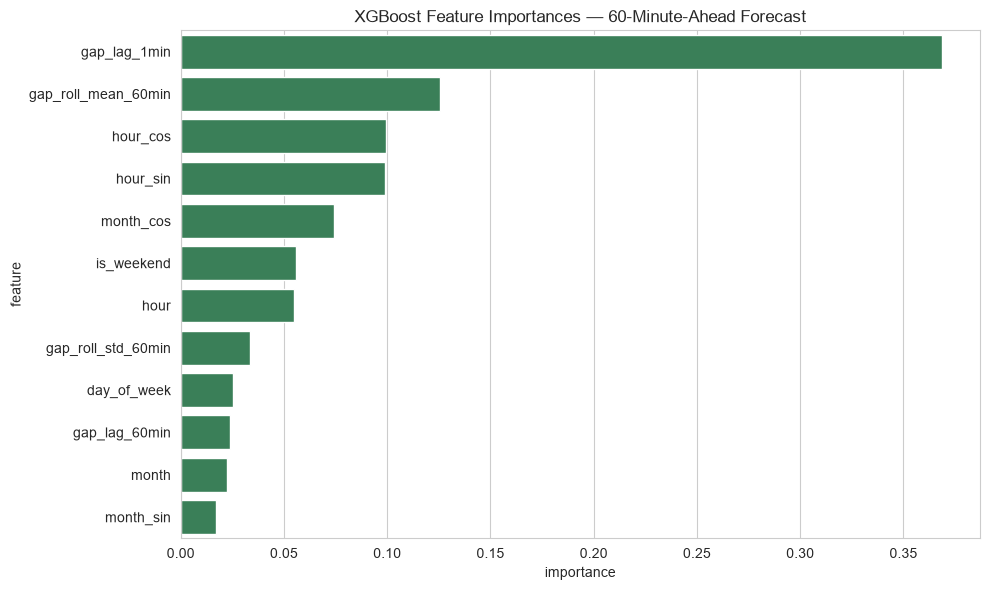

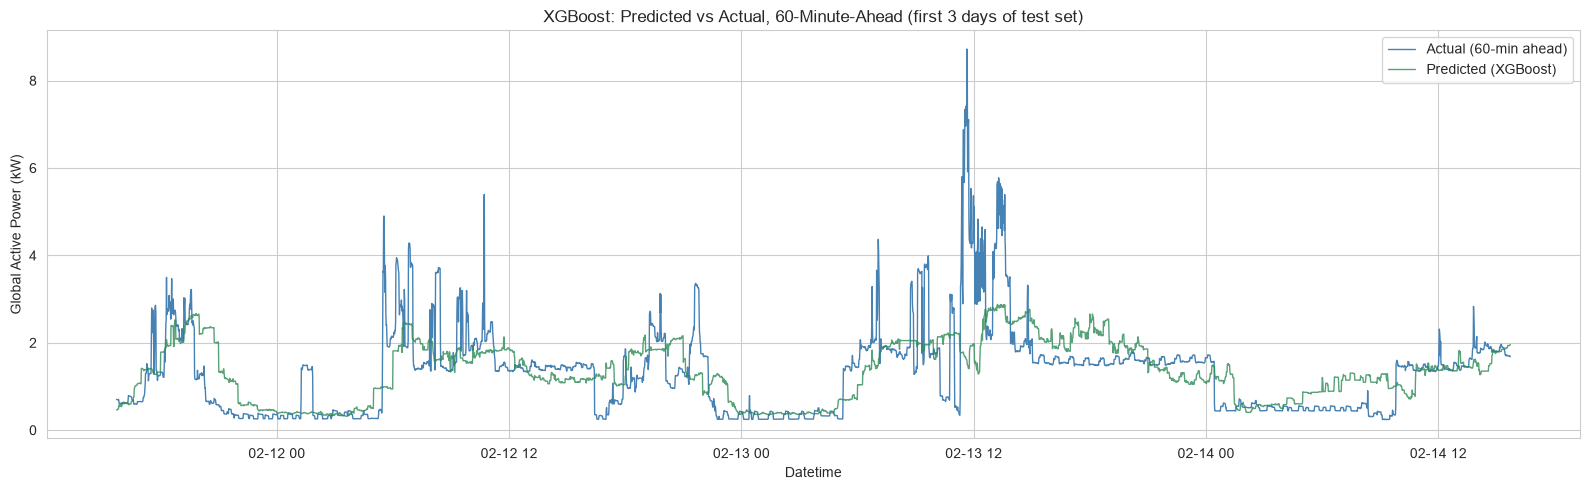

In [19]:
# =========================================================
# STEP 18: Gradient Boosting (XGBoost) — 60-Minute-Ahead Forecast
# =========================================================

# !pip install xgboost
from xgboost import XGBRegressor

# ---- 18.1 Carve a validation set from the END of the training period (still chronological) ----
val_split_idx = int(len(X_train_60) * 0.9)  # last 10% of training period as validation

X_train_fit = X_train_60.iloc[:val_split_idx]
y_train_fit = y_train_60.iloc[:val_split_idx]
X_val = X_train_60.iloc[val_split_idx:]
y_val = y_train_60.iloc[val_split_idx:]

print(f"Fit set:  {X_train_fit.shape[0]} rows ({X_train_fit.index.min()} to {X_train_fit.index.max()})")
print(f"Val set:  {X_val.shape[0]} rows ({X_val.index.min()} to {X_val.index.max()})")
print(f"Test set: {X_test_60.shape[0]} rows ({X_test_60.index.min()} to {X_test_60.index.max()})")

# ---- 18.2 Fit XGBoost with early stopping on the validation set ----
xgb_60 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=20,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
xgb_60.fit(
    X_train_fit, y_train_fit,
    eval_set=[(X_val, y_val)],
    verbose=False
)
fit_time_xgb = time.time() - start_time

print(f"\nXGBoost fit in {fit_time_xgb:.1f} seconds")
print(f"Best iteration (early stopping): {xgb_60.best_iteration}")

# ---- 18.3 Predict on the true held-out test set ----
y_pred_xgb_60 = xgb_60.predict(X_test_60)

mae_xgb_60 = mean_absolute_error(y_test_60, y_pred_xgb_60)
rmse_xgb_60 = np.sqrt(mean_squared_error(y_test_60, y_pred_xgb_60))
r2_xgb_60 = r2_score(y_test_60, y_pred_xgb_60)

print("\nXGBoost — Test Set Performance (60-min-ahead):")
print(f"  MAE:  {mae_xgb_60:.4f} kW")
print(f"  RMSE: {rmse_xgb_60:.4f} kW")
print(f"  R²:   {r2_xgb_60:.4f}")

# ---- 18.4 Three-way comparison at the 60-min horizon ----
comparison_xgb = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [mae_lr_60, mae_rf_60, mae_xgb_60],
    "RMSE": [rmse_lr_60, rmse_rf_60, rmse_xgb_60],
    "R2": [r2_lr_60, r2_rf_60, r2_xgb_60]
})
print("\n60-Minute-Ahead Model Comparison:")
display(comparison_xgb)

# ---- 18.5 Feature importances ----
importance_xgb = pd.DataFrame({
    "feature": X_train_60.columns,
    "importance": xgb_60.feature_importances_
}).sort_values("importance", ascending=False)

print("\nXGBoost feature importances:")
display(importance_xgb)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_xgb, x="importance", y="feature", color="seagreen")
plt.title("XGBoost Feature Importances — 60-Minute-Ahead Forecast")
plt.tight_layout()
plt.savefig("Charts/12_xgb_feature_importances_60min.png", dpi=150)
plt.show()

# ---- 18.6 Visual: predicted vs actual, sample window (60-min-ahead target) ----
sample_start_60 = X_test_60.index.min()
sample_end_60 = sample_start_60 + pd.Timedelta(days=3)

plt.figure(figsize=(16, 5))
plt.plot(y_test_60.loc[sample_start_60:sample_end_60], label="Actual (60-min ahead)", color="steelblue", linewidth=1)
plt.plot(pd.Series(y_pred_xgb_60, index=X_test_60.index).loc[sample_start_60:sample_end_60],
          label="Predicted (XGBoost)", color="seagreen", linewidth=1, alpha=0.8)
plt.title("XGBoost: Predicted vs Actual, 60-Minute-Ahead (first 3 days of test set)")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig("Charts/13_xgb_predicted_vs_actual.png", dpi=150)
plt.show()

## Step 19: Additional Feature Engineering — More Lags & a Seasonal Proxy

We're going to expand our feature set with two categories of new signal, all still computed strictly from information available *before* the prediction timestamp `t` (no leakage):

**More granular lag structure:**
Our current features jump straight from `t-1` to `t-60`, skipping the shape of what happened in between. We add `t-5`, `t-15`, and `t-30` minute lags to give the model a finer-grained view of the recent trajectory — e.g., "was consumption rising or falling over the last half hour" is very different information than a single snapshot at `t-1` or `t-60`.

**A same-time-yesterday feature (our "seasonal proxy"):**
We don't have real weather data available, but consumption is strongly driven by daily routine, which repeats with a ~24-hour period. We add `gap_lag_1440min` — the value from exactly 24 hours before `t` — as a proxy for "what does a typical day look like at this hour." This acts similarly to how a weather-driven feature would: it encodes an expected baseline for this specific hour-of-day without needing external data we don't have.

**A longer rolling window:**
We add `gap_roll_mean_180min` (3-hour rolling mean) alongside our existing 60-minute one, to capture a slower-moving trend signal — useful since our 60-min-ahead target is itself a fairly long horizon, and a 3-hour trend may be more informative than a 1-hour one for that kind of forecast.

We rebuild the strict, forecasting-safe feature set with these additions, re-establish the 60-min-ahead train/test split (dropping any new leading rows the longer lags introduce), and re-run XGBoost — our best performer so far — to see whether the richer feature set pushes R² meaningfully past 0.348.

Rows before dropna: 2075259
Rows after dropna:  2073759
Rows dropped: 1500 (leading lag NaNs + trailing target NaNs)

Train shape: (1658780, 17)
Test shape:  (414980, 17)

XGBoost (expanded features) fit in 24.0s, best iteration: 201

Expanded-Feature XGBoost — Test Set Performance (60-min-ahead):
  MAE:  0.4860 kW
  RMSE: 0.7111 kW
  R²:   0.3572

Comparison — original vs expanded features:


,Model,MAE,RMSE,R2
0,"XGBoost (12 features, Step 18)",0.489462,0.716049,0.348250
1,"XGBoost (17 features, Step 19)",0.486045,0.711110,0.357209



Feature importances (expanded model):


,feature,importance
8,gap_lag_1min,0.256684
9,gap_lag_5min,0.252168
5,hour_cos,0.071054
4,hour_sin,0.064862
7,month_cos,0.061855
3,is_weekend,0.050949
14,gap_roll_mean_60min,0.048207
10,gap_lag_15min,0.045703
0,hour,0.038062
1,day_of_week,0.020554


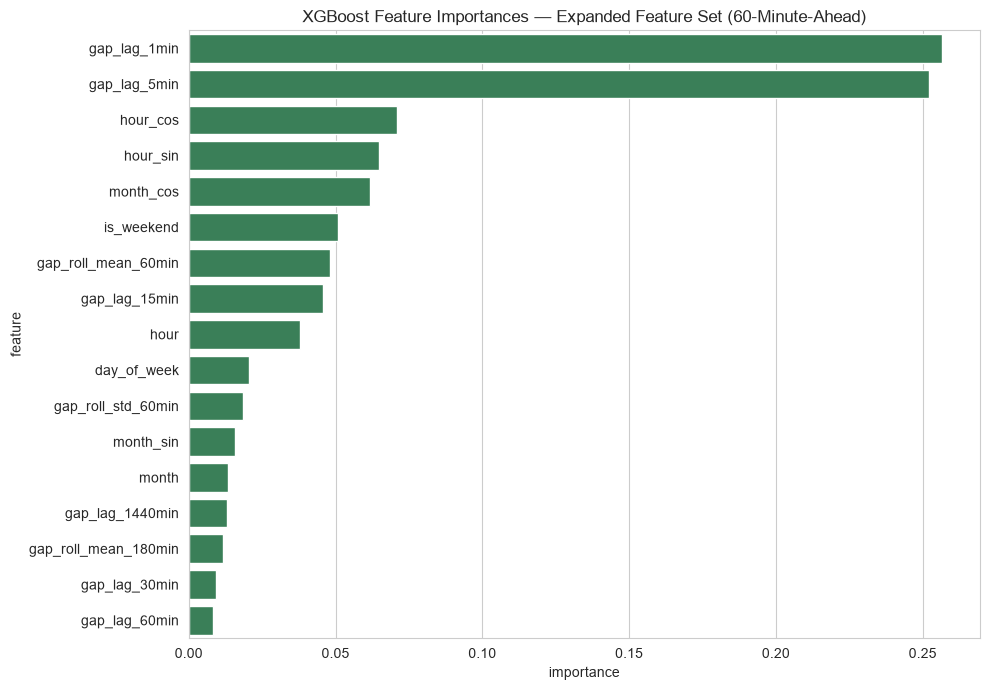

In [20]:
# =========================================================
# STEP 19: Additional Feature Engineering — More Lags & Seasonal Proxy
# =========================================================

df_v2 = X_clean.copy()

# ---- 19.1 Rebuild calendar/cyclical features (same as Step 9) ----
df_v2["hour"] = df_v2.index.hour
df_v2["day_of_week"] = df_v2.index.dayofweek
df_v2["month"] = df_v2.index.month
df_v2["is_weekend"] = (df_v2["day_of_week"] >= 5).astype(int)
df_v2["hour_sin"] = np.sin(2 * np.pi * df_v2["hour"] / 24)
df_v2["hour_cos"] = np.cos(2 * np.pi * df_v2["hour"] / 24)
df_v2["month_sin"] = np.sin(2 * np.pi * df_v2["month"] / 12)
df_v2["month_cos"] = np.cos(2 * np.pi * df_v2["month"] / 12)

# ---- 19.2 Expanded lag features ----
for lag in [1, 5, 15, 30, 60, 1440]:
    df_v2[f"gap_lag_{lag}min"] = df_v2["Global_active_power"].shift(lag)

# ---- 19.3 Rolling window features (60min existing + new 180min) ----
df_v2["gap_roll_mean_60min"] = df_v2["Global_active_power"].shift(1).rolling(window=60).mean()
df_v2["gap_roll_std_60min"] = df_v2["Global_active_power"].shift(1).rolling(window=60).std()
df_v2["gap_roll_mean_180min"] = df_v2["Global_active_power"].shift(1).rolling(window=180).mean()

# ---- 19.4 Build the 60-min-ahead target (same as Step 17) ----
df_v2["target_60min"] = df_v2["Global_active_power"].shift(-HORIZON)

# ---- 19.5 Drop rows with any NaN (leading lag NaNs + trailing target NaNs) ----
strict_feature_cols_v2 = [
    "hour", "day_of_week", "month", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "gap_lag_1min", "gap_lag_5min", "gap_lag_15min", "gap_lag_30min", "gap_lag_60min", "gap_lag_1440min",
    "gap_roll_mean_60min", "gap_roll_std_60min", "gap_roll_mean_180min"
]

model_df_v2 = df_v2[strict_feature_cols_v2 + ["target_60min"]].dropna()
print(f"Rows before dropna: {len(df_v2)}")
print(f"Rows after dropna:  {len(model_df_v2)}")
print(f"Rows dropped: {len(df_v2) - len(model_df_v2)} (leading lag NaNs + trailing target NaNs)")

# ---- 19.6 Chronological split, using the SAME split date as before for consistency ----
X_v2 = model_df_v2[strict_feature_cols_v2]
y_v2 = model_df_v2["target_60min"]

X_train_v2 = X_v2.loc[:split_date]
X_test_v2 = X_v2.loc[split_date:]
y_train_v2 = y_v2.loc[:split_date]
y_test_v2 = y_v2.loc[split_date:]

print(f"\nTrain shape: {X_train_v2.shape}")
print(f"Test shape:  {X_test_v2.shape}")

# ---- 19.7 Re-fit XGBoost with the expanded feature set ----
val_split_idx_v2 = int(len(X_train_v2) * 0.9)
X_train_fit_v2 = X_train_v2.iloc[:val_split_idx_v2]
y_train_fit_v2 = y_train_v2.iloc[:val_split_idx_v2]
X_val_v2 = X_train_v2.iloc[val_split_idx_v2:]
y_val_v2 = y_train_v2.iloc[val_split_idx_v2:]

xgb_v2 = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    early_stopping_rounds=20, eval_metric="rmse",
    random_state=42, n_jobs=-1
)

start_time = time.time()
xgb_v2.fit(X_train_fit_v2, y_train_fit_v2, eval_set=[(X_val_v2, y_val_v2)], verbose=False)
fit_time_v2 = time.time() - start_time

y_pred_v2 = xgb_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_v2))
r2_v2 = r2_score(y_test_v2, y_pred_v2)

print(f"\nXGBoost (expanded features) fit in {fit_time_v2:.1f}s, best iteration: {xgb_v2.best_iteration}")
print("\nExpanded-Feature XGBoost — Test Set Performance (60-min-ahead):")
print(f"  MAE:  {mae_v2:.4f} kW")
print(f"  RMSE: {rmse_v2:.4f} kW")
print(f"  R²:   {r2_v2:.4f}")

# ---- 19.8 Compare against original XGBoost (12 features, Step 18) ----
comparison_v2 = pd.DataFrame({
    "Model": ["XGBoost (12 features, Step 18)", "XGBoost (17 features, Step 19)"],
    "MAE": [mae_xgb_60, mae_v2],
    "RMSE": [rmse_xgb_60, rmse_v2],
    "R2": [r2_xgb_60, r2_v2]
})
print("\nComparison — original vs expanded features:")
display(comparison_v2)

# ---- 19.9 Feature importances ----
importance_v2 = pd.DataFrame({
    "feature": X_train_v2.columns,
    "importance": xgb_v2.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature importances (expanded model):")
display(importance_v2)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_v2, x="importance", y="feature", color="seagreen")
plt.title("XGBoost Feature Importances — Expanded Feature Set (60-Minute-Ahead)")
plt.tight_layout()
plt.savefig("Charts/14_xgb_v2_feature_importances.png", dpi=150)
plt.show()

## Step 20: Final Model Selection & Persistence

We wrap up the modeling phase by consolidating everything into a final, reproducible summary. Across this project we tested two distinct forecasting horizons and four models, catching and correcting two real data leakage issues along the way. Our best-performing, leakage-free model is **XGBoost with the expanded feature set (Step 19)**, forecasting 60 minutes ahead:

- **R² = 0.357** — the model explains ~36% of the variance in consumption an hour ahead, a modest but genuine result given the inherent unpredictability of individual appliance usage.
- **MAE = 0.486 kW** — on average, predictions are off by under half a kilowatt.
- **RMSE = 0.711 kW** — slightly higher than MAE, reflecting the occasional large miss during sharp appliance spikes, which we visually confirmed earlier the model structurally cannot capture (spikes are only knowable once they actually happen).

We save this final model, its feature list, and a consolidated results table — everything needed to reproduce or deploy this result later, or to build the reporting deliverables (README, presentation, results narrative) on top of.

Final Project Results Summary:


,Model,Horizon,MAE_kW,RMSE_kW,R2
0,"Linear Regression (1-min ahead, leakage-free)",1 min,0.083357,0.217660,0.939774
1,Random Forest (1-min ahead),1 min,0.080470,0.215301,0.941072
2,Linear Regression (60-min ahead),60 min,0.544056,0.774726,0.237057
3,Random Forest (60-min ahead),60 min,0.498777,0.742340,0.299511
4,"XGBoost (60-min ahead, 12 features)",60 min,0.489462,0.716049,0.348250
5,"XGBoost (60-min ahead, 17 features) — FINAL",60 min,0.486045,0.711110,0.357209



Final model saved to: Cleaned_Datasets/final_xgboost_60min_model.pkl
Feature list saved to: Reports/final_model_features.txt
Results table saved to: Reports/final_model_comparison.csv


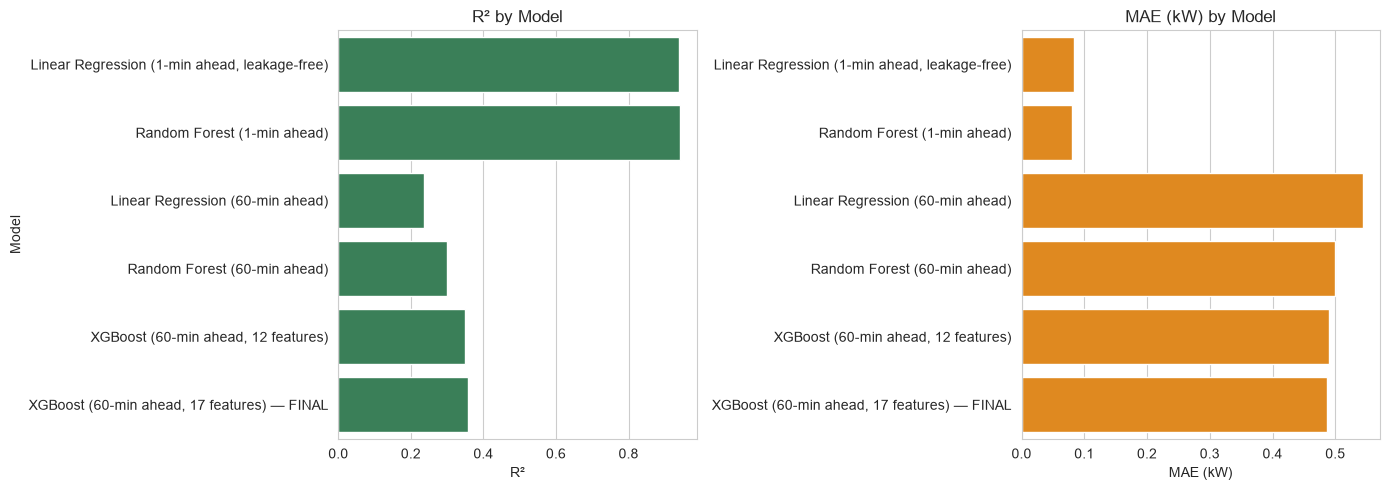


PROJECT COMPLETE
Best model: XGBoost (60-min-ahead, 17 features)
Final performance: R²=0.3572, MAE=0.4860 kW, RMSE=0.7111 kW


In [21]:
# =========================================================
# STEP 20: Final Model Selection & Persistence
# =========================================================

# ---- 20.1 Consolidated results table across the full project ----
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression (1-min ahead, leakage-free)",
        "Random Forest (1-min ahead)",
        "Linear Regression (60-min ahead)",
        "Random Forest (60-min ahead)",
        "XGBoost (60-min ahead, 12 features)",
        "XGBoost (60-min ahead, 17 features) — FINAL"
    ],
    "Horizon": ["1 min", "1 min", "60 min", "60 min", "60 min", "60 min"],
    "MAE_kW": [mae_strict, mae_rf, mae_lr_60, mae_rf_60, mae_xgb_60, mae_v2],
    "RMSE_kW": [rmse_strict, rmse_rf, rmse_lr_60, rmse_rf_60, rmse_xgb_60, rmse_v2],
    "R2": [r2_strict, r2_rf, r2_lr_60, r2_rf_60, r2_xgb_60, r2_v2]
})

print("Final Project Results Summary:")
display(final_results)

final_results.to_csv("Reports/final_model_comparison.csv", index=False)

# ---- 20.2 Save the final model and its feature list ----
joblib.dump(xgb_v2, "Cleaned_Datasets/final_xgboost_60min_model.pkl")

with open("Reports/final_model_features.txt", "w") as f:
    f.write("Final Model: XGBoost (60-minute-ahead forecast)\n")
    f.write("Features used:\n")
    for feat in X_train_v2.columns:
        f.write(f"  - {feat}\n")

print("\nFinal model saved to: Cleaned_Datasets/final_xgboost_60min_model.pkl")
print("Feature list saved to: Reports/final_model_features.txt")
print("Results table saved to: Reports/final_model_comparison.csv")

# ---- 20.3 Final visual summary: model comparison bar chart ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=final_results, x="R2", y="Model", ax=axes[0], color="seagreen")
axes[0].set_title("R² by Model")
axes[0].set_xlabel("R²")

sns.barplot(data=final_results, x="MAE_kW", y="Model", ax=axes[1], color="darkorange")
axes[1].set_title("MAE (kW) by Model")
axes[1].set_xlabel("MAE (kW)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("Charts/15_final_model_comparison.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("PROJECT COMPLETE")
print("="*60)
print(f"Best model: XGBoost (60-min-ahead, 17 features)")
print(f"Final performance: R²={r2_v2:.4f}, MAE={mae_v2:.4f} kW, RMSE={rmse_v2:.4f} kW")